# Deep Learning Project Development Summary (FYS-3033)

This document summarizes the key development steps, architectural design choices, and clever improvements made during the implementation of the deep learning classifier for the home exam in FYS-3033. This is a behind-the-scenes overview of the insights and decisions made to refine the workflow, training pipeline, and model performance.

---

## 🔧 General Improvements and Workflow Design

### ✅ Modular Code Structure
- **Split into `src/` submodules**:
  - `vgg11bn.py`: Manually implemented VGG-11 with BatchNorm & optional Dropout.
  - `train.py`: Self-contained training loop with live tqdm feedback, logging, model saving.
  - `utils.py`: Contains custom Dataset, entropy function, seed function, etc.
  - `evaluation.py`: Confusion matrix, classification report, ROC/entropy plotting.

### 📑 Project Tree Setup
- Ensured clean file/folder separation using `.gitignore`, `plots/`, `logs/`, `models/`, and `doc/` folders.
- Included `.gitkeep` files for empty folders to retain structure in git.
- Used `show_tree.py` to quickly inspect and visualize directory contents.

### 🔎 Debugging and Reproducibility
- **Created `set_seed()` function** to fix random seeds for PyTorch, NumPy, and CUDA.
- Identified issues with `__pycache__` and `*.ipynb_checkpoints` interfering with Git commits.
- Learned how to clean up git merge/commit issues using `rm .git/index.lock` and reset commands.

---

## 🏋️ Model Architecture (VGG-11 BN)

### ⚖️ Design Justifications
- Started with VGG-11 (column A in Simonyan & Zisserman) + added BatchNorm after every Conv.
- Made `Dropout` optional using:
  ```python
  nn.Dropout(p=0.5) if self.dropout else nn.Identity()
  ```
  This smart use of `nn.Identity()` ensured flexible model instantiation.

### 🌀 Improvements Made
- Switched `stride=1` and `padding=1` in Conv layers to preserve spatial resolution.
- Used `.view(x.size(0), -1)` instead of `.flatten()` for safety and PyTorch consistency.

---

## ⏳ Training Pipeline Enhancements

### 📊 Metrics Logging
- Tracked and stored `train_loss`, `val_loss`, `val_acc` into CSV files.
- Automatically plotted curves and saved them as `.png`.
- Example:
  ```bash
  logs/VGG11BN_2c_with_dropout_metrics.csv
  plots/VGG11BN_2c_with_dropout_training.png
  ```

### 🎭 Live Feedback with tqdm
- Swapped out standard loops with `tqdm()` and live metric updates:
  ```python
  loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.4f}")
  ```

### 📈 Model Evaluation
- Implemented:
  - `classification_summary()` with support for returning final val loss and acc
  - `plot_confusion_matrix()` using `sklearn`
  - `plot_multiclass_roc()` for ROC curve analysis per class
  - `print_framed_metrics()` to display results in clean framed output.

---

## 🔢 Experiments Conducted

### Config Table
| Model Name | Dropout | Weight Decay | Scheduler |
|------------|---------|---------------|-----------|
| 2a - Baseline | No | No | No |
| 2a - +WD | No | 1e-4 | No |
| 2a - +WD+Sched | No | 1e-4 | Yes |
| 2c - Dropout | Yes | No | No |
| 2c - +WD | Yes | 1e-4 | No |
| 2c - +WD+Sched | Yes | 1e-4 | Yes |

### Results (example summary)
| Model | Val Loss | Val Acc |
|--------|----------|----------|64
| 2a | 0.9112 | 0.8900 |
| 2c | 0.7322 | 0.8833 |

---

## 📅 Git & Notebook Handling

- Avoided tracking notebook-generated artifacts (`__pycache__`, `checkpoints`, etc.)
- Pushed Jupyter results only when needed.
- Used `git rm --cached file` and `.gitignore` to keep the repo clean.

---

## 🌍 General Takeaways

- ✅ Dropout helped lower validation loss (better calibration), despite small drop in accuracy.
- ✅ Weight decay + learning rate scheduler stabilized training.
- ❌ Batch size was constant (32), but future work may test 64/128 for throughput vs. stability.
- ☑️ All model performance metrics are reproducible and properly logged/saved.

---



training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


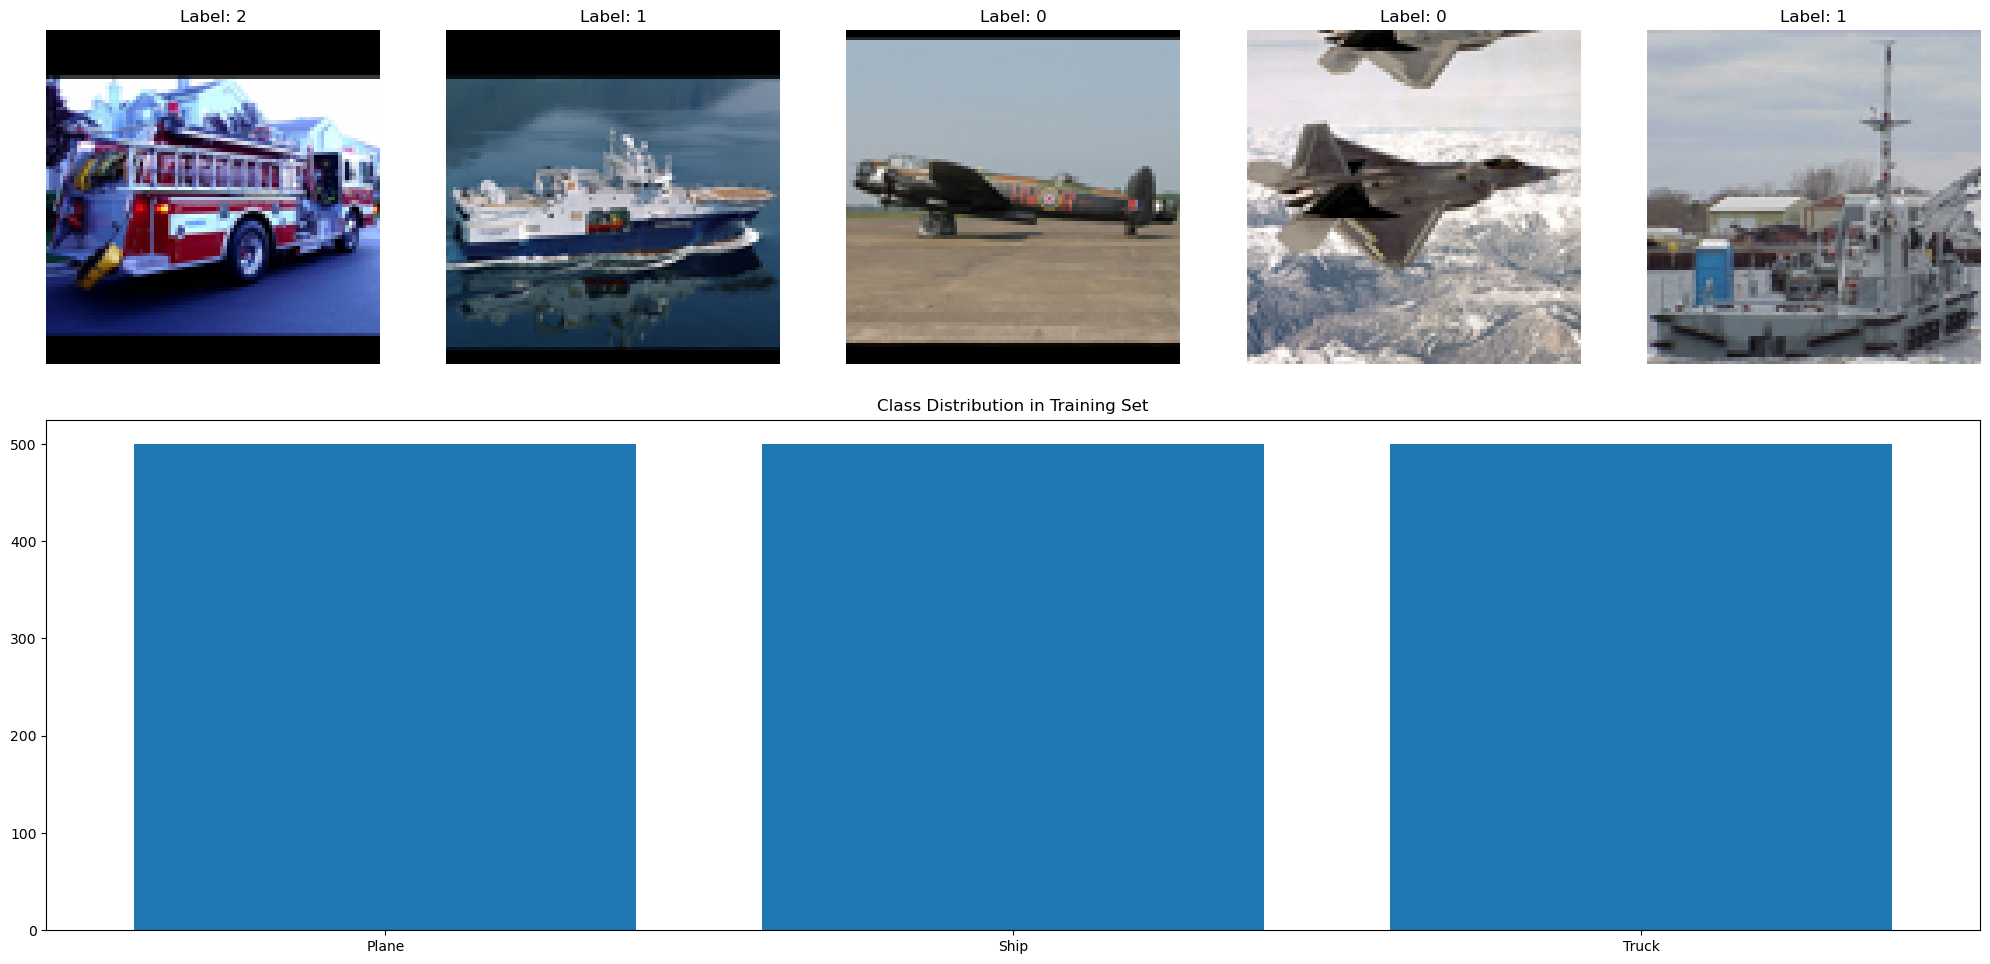

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


In [2]:
from sklearn.model_selection import train_test_split



# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


In [3]:
# from torch.utils.data import DataLoader
# from src.utils import ImageDataset

# # Create datasets
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# # Create loaders
# dataloaders = {
#     'train': DataLoader(
#         train_dataset,
#         batch_size=32,
#         shuffle=True,           #  Shuffles training data each epoch
#         pin_memory=True         #  Speeds up transfer to GPU (if using CUDA)
#     ),
#     'val': DataLoader(
#         val_dataset,
#         batch_size=32,
#         shuffle=False,          #  Keeps validation consistent across epochs
#         pin_memory=True         #  Still helpful for val on GPU
#     )
# }




=== Training: VGG11BN_2a_no_dropout (Batch size: 32) ===


Training VGG11BN_2a_no_dropout_bs32_20250414_212007: 100%|██████████| 2880/2880 [02:18<00:00, 20.75batch/s, epoch=60/60, phase=val, loss=1.3455, acc=0.9167]  



Best Val Accuracy: 0.9000
Total training time: 138.77s


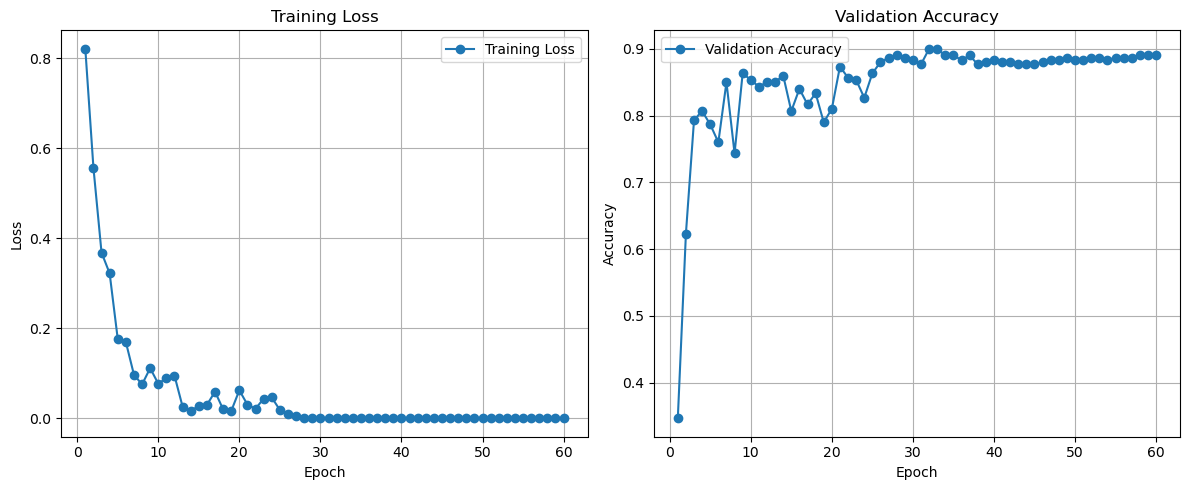

              precision    recall  f1-score   support

       Plane       0.92      0.88      0.90       100
        Ship       0.90      0.83      0.86       100
       Truck       0.86      0.96      0.91       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.7407, Validation Accuracy: 0.8900 |
+------------------------------------------------------+


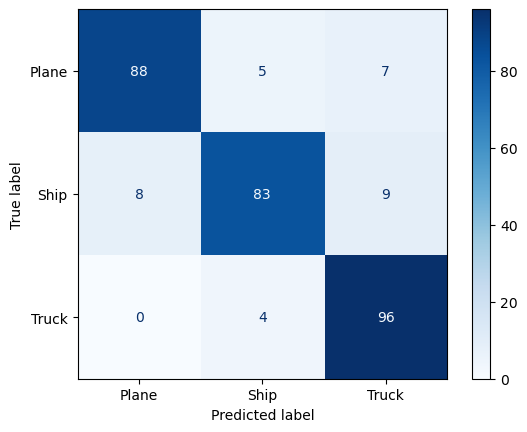

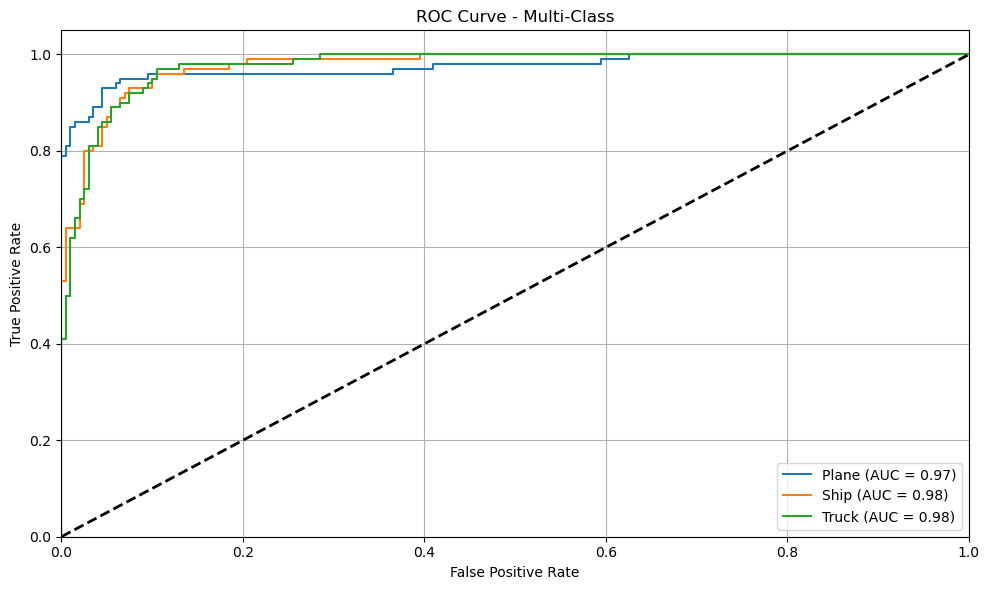

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_bs32.png


=== Training: VGG11BN_2a_no_dropout_weightdecay (Batch size: 32) ===


Training VGG11BN_2a_no_dropout_weightdecay_bs32_20250414_212228: 100%|██████████| 2880/2880 [02:26<00:00, 19.67batch/s, epoch=60/60, phase=val, loss=1.3797, acc=0.8333]  



Best Val Accuracy: 0.9067
Total training time: 146.45s


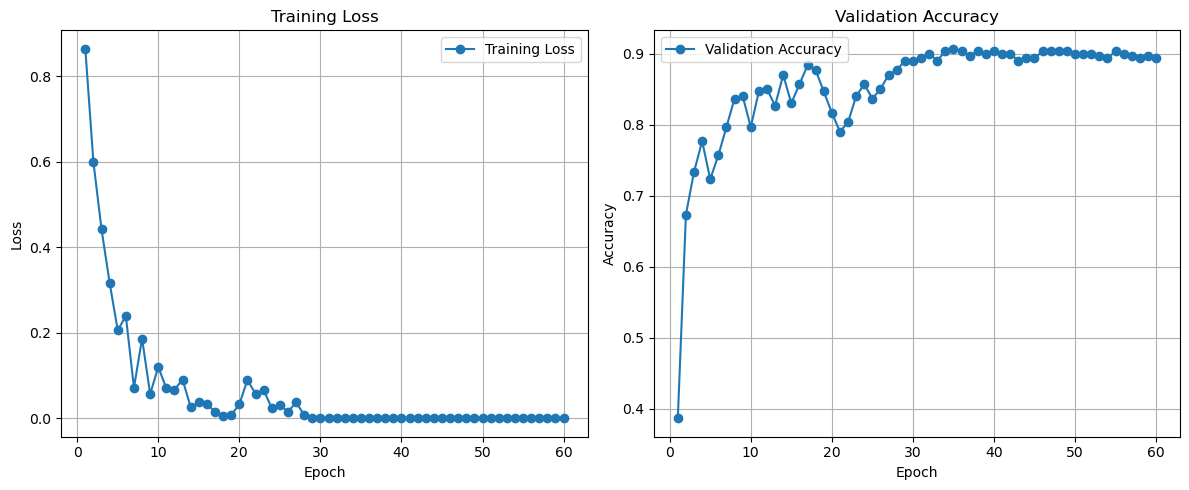

              precision    recall  f1-score   support

       Plane       0.94      0.89      0.91       100
        Ship       0.87      0.88      0.88       100
       Truck       0.88      0.91      0.89       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.5532, Validation Accuracy: 0.8933 |
+------------------------------------------------------+


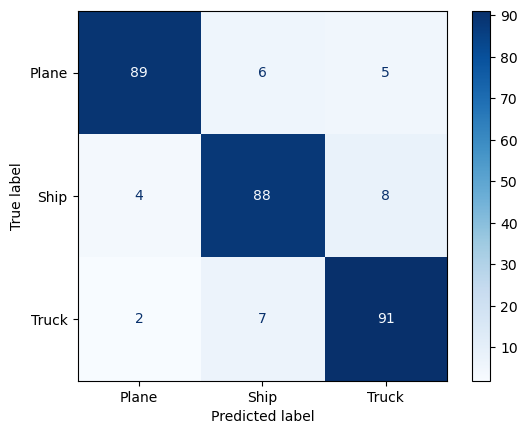

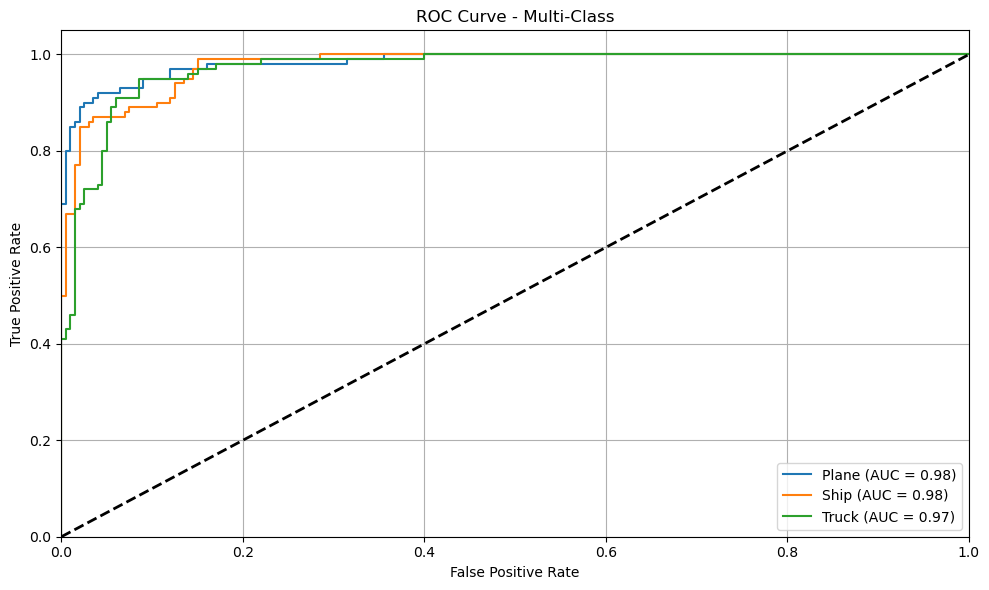

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_bs32.png


=== Training: VGG11BN_2a_no_dropout_weightdecay_scheduler (Batch size: 32) ===


Training VGG11BN_2a_no_dropout_weightdecay_scheduler_bs32_20250414_212456: 100%|██████████| 2880/2880 [02:27<00:00, 19.49batch/s, epoch=60/60, phase=val, loss=1.1399, acc=0.8333]  



Best Val Accuracy: 0.9100
Total training time: 147.77s


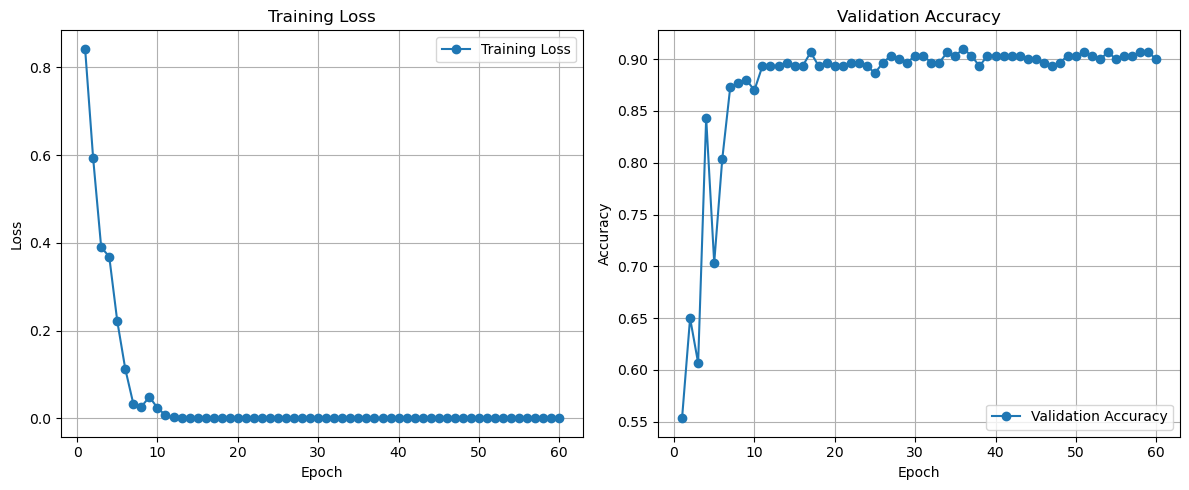

              precision    recall  f1-score   support

       Plane       0.97      0.88      0.92       100
        Ship       0.87      0.91      0.89       100
       Truck       0.88      0.91      0.89       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.4317, Validation Accuracy: 0.9000 |
+------------------------------------------------------+


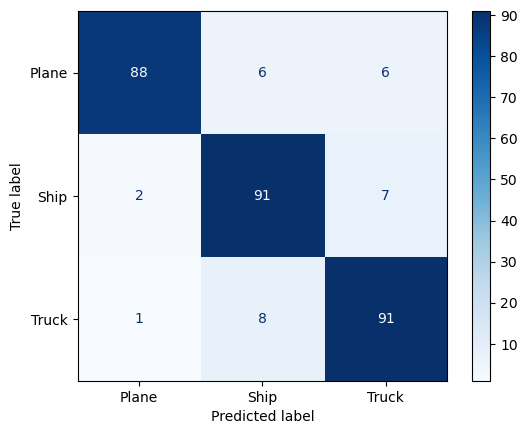

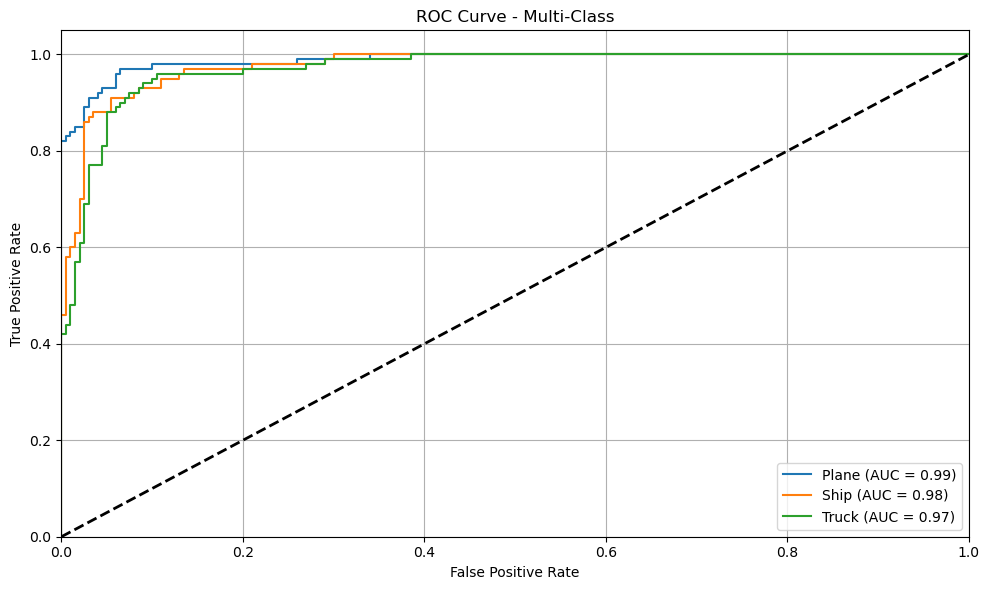

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_scheduler_bs32.png


=== Training: VGG11BN_2c_with_dropout (Batch size: 32) ===


Training VGG11BN_2c_with_dropout_bs32_20250414_212726: 100%|██████████| 2880/2880 [02:23<00:00, 20.06batch/s, epoch=60/60, phase=val, loss=2.3188, acc=0.8333]  



Best Val Accuracy: 0.8967
Total training time: 143.54s


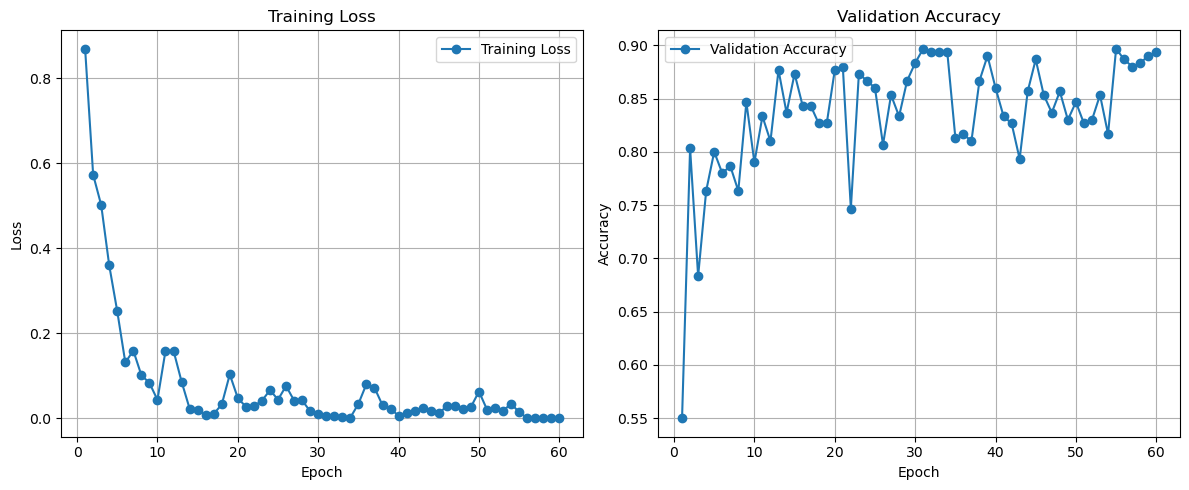

              precision    recall  f1-score   support

       Plane       0.95      0.91      0.93       100
        Ship       0.85      0.87      0.86       100
       Truck       0.88      0.90      0.89       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.6461, Validation Accuracy: 0.8933 |
+------------------------------------------------------+


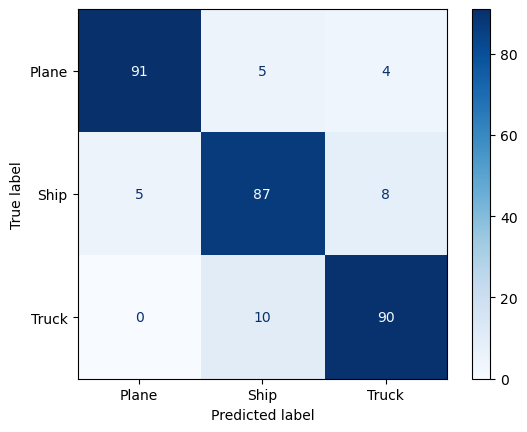

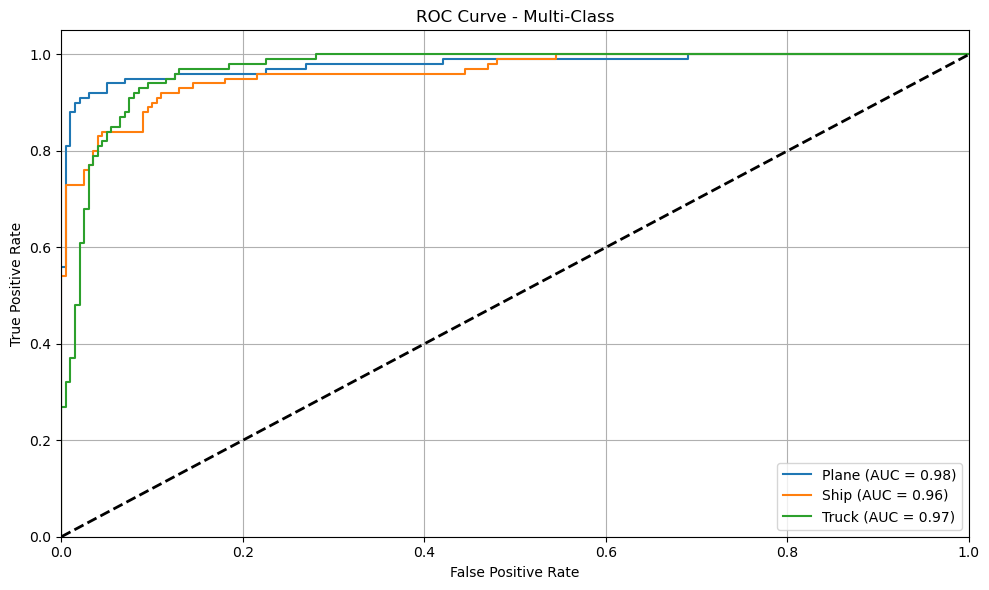

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_bs32.png


=== Training: VGG11BN_2c_with_dropout_weightdecay (Batch size: 32) ===


Training VGG11BN_2c_with_dropout_weightdecay_bs32_20250414_212952: 100%|██████████| 2880/2880 [02:27<00:00, 19.48batch/s, epoch=60/60, phase=val, loss=2.0090, acc=0.7500]  



Best Val Accuracy: 0.9167
Total training time: 147.86s


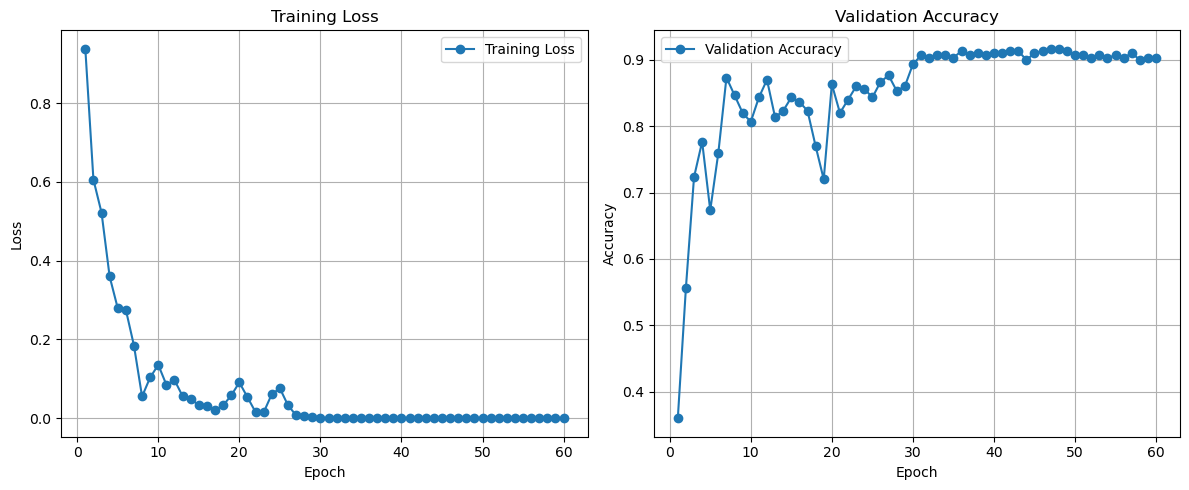

              precision    recall  f1-score   support

       Plane       0.96      0.87      0.91       100
        Ship       0.89      0.91      0.90       100
       Truck       0.87      0.93      0.90       100

    accuracy                           0.90       300
   macro avg       0.91      0.90      0.90       300
weighted avg       0.91      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.5429, Validation Accuracy: 0.9033 |
+------------------------------------------------------+


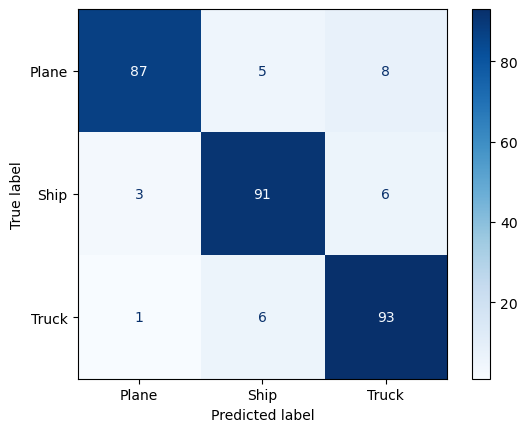

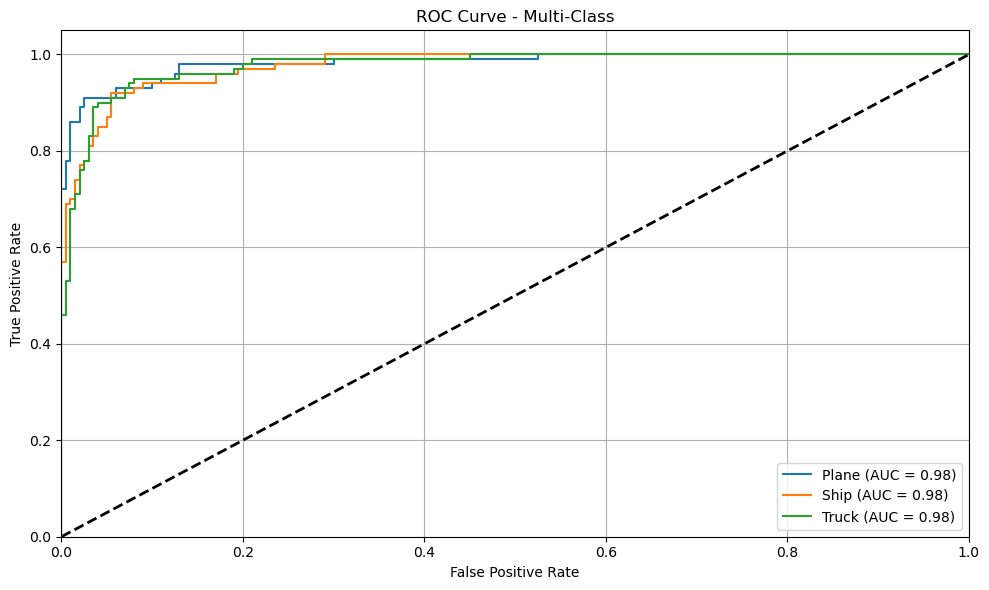

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_bs32.png


=== Training: VGG11BN_2c_with_dropout_weightdecay_scheduler (Batch size: 32) ===


Training VGG11BN_2c_with_dropout_weightdecay_scheduler_bs32_20250414_213222: 100%|██████████| 2880/2880 [02:27<00:00, 19.50batch/s, epoch=60/60, phase=val, loss=1.1999, acc=0.8333]  



Best Val Accuracy: 0.9000
Total training time: 147.69s


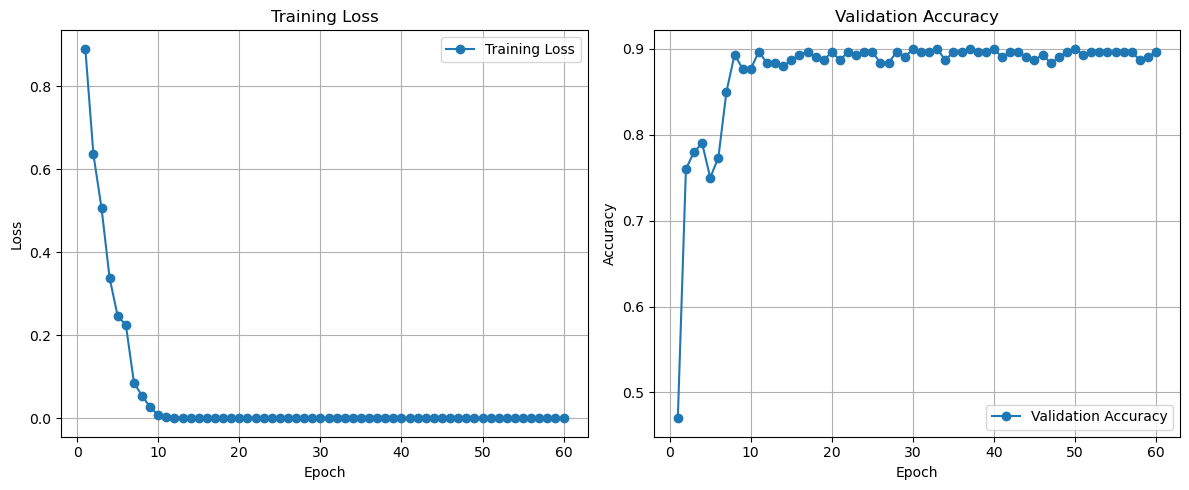

              precision    recall  f1-score   support

       Plane       0.98      0.87      0.92       100
        Ship       0.87      0.91      0.89       100
       Truck       0.86      0.91      0.88       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.4958, Validation Accuracy: 0.8967 |
+------------------------------------------------------+


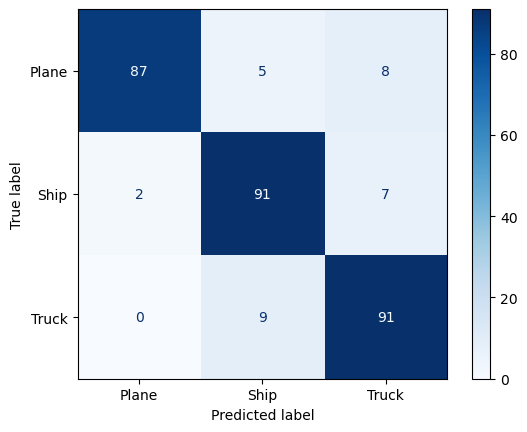

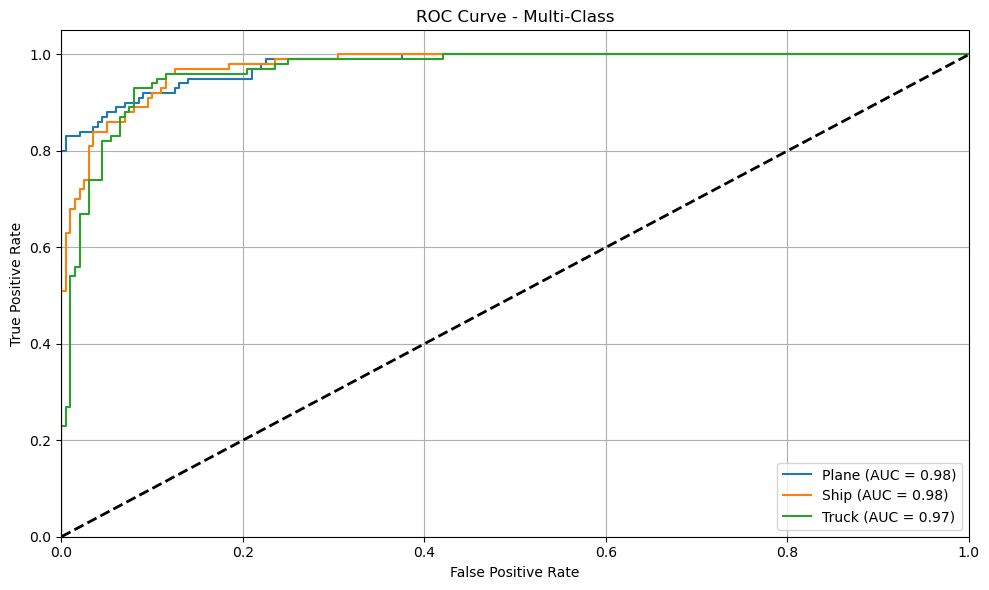

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_scheduler_bs32.png


=== Training: VGG11BN_2a_no_dropout (Batch size: 64) ===


Training VGG11BN_2a_no_dropout_bs64_20250414_213452: 100%|██████████| 1440/1440 [02:03<00:00, 11.65batch/s, epoch=60/60, phase=val, loss=0.8901, acc=0.8864]  



Best Val Accuracy: 0.8967
Total training time: 123.58s


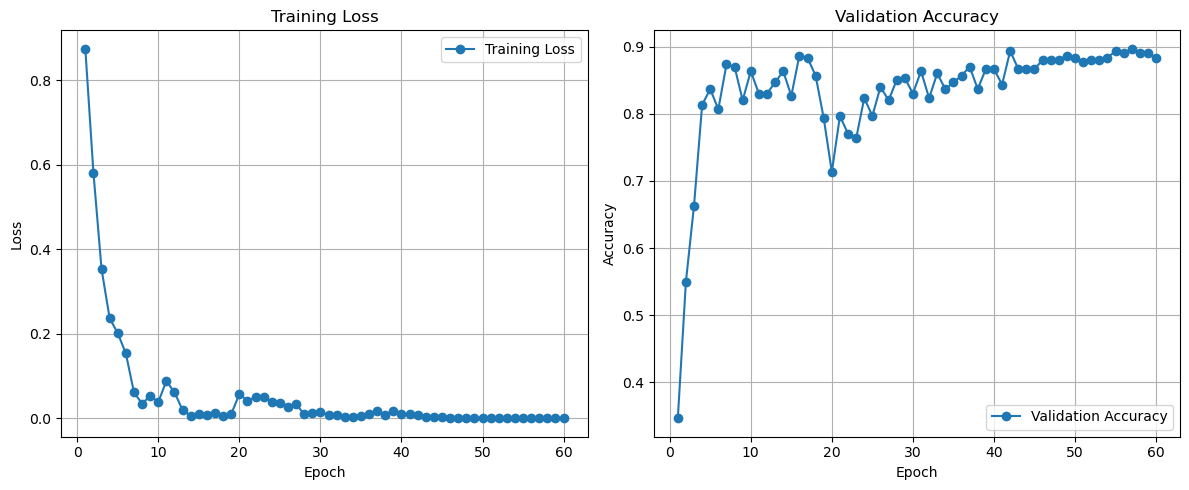

              precision    recall  f1-score   support

       Plane       0.95      0.87      0.91       100
        Ship       0.87      0.85      0.86       100
       Truck       0.85      0.93      0.89       100

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.8791, Validation Accuracy: 0.8833 |
+------------------------------------------------------+


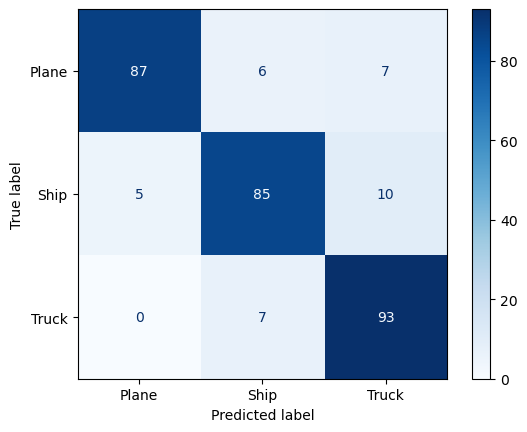

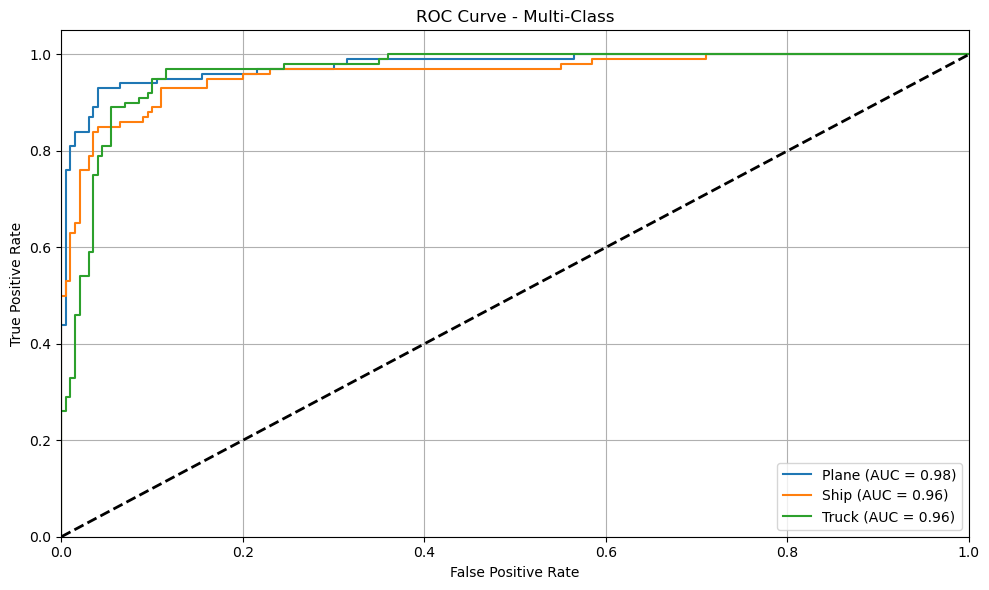

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_bs64.png


=== Training: VGG11BN_2a_no_dropout_weightdecay (Batch size: 64) ===


Training VGG11BN_2a_no_dropout_weightdecay_bs64_20250414_213657: 100%|██████████| 1440/1440 [02:04<00:00, 11.52batch/s, epoch=60/60, phase=val, loss=0.8532, acc=0.8182]  



Best Val Accuracy: 0.8733
Total training time: 124.96s


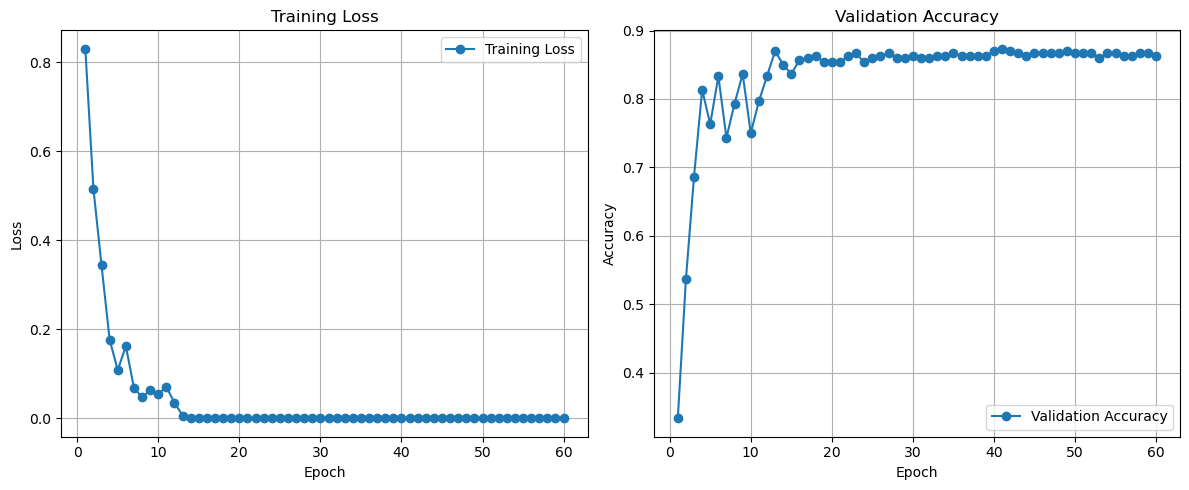

              precision    recall  f1-score   support

       Plane       0.96      0.85      0.90       100
        Ship       0.82      0.86      0.84       100
       Truck       0.83      0.88      0.85       100

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300

+------------------------------------------------------+
| Validation Loss: 0.6023, Validation Accuracy: 0.8633 |
+------------------------------------------------------+


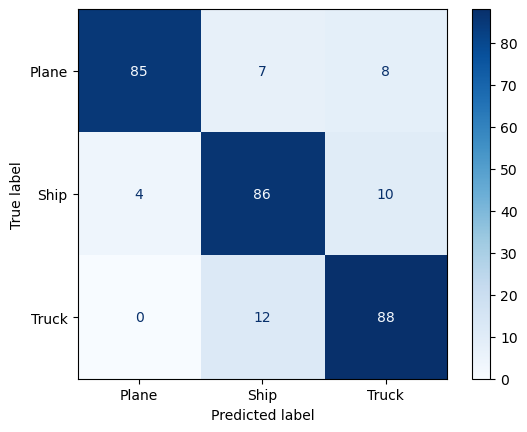

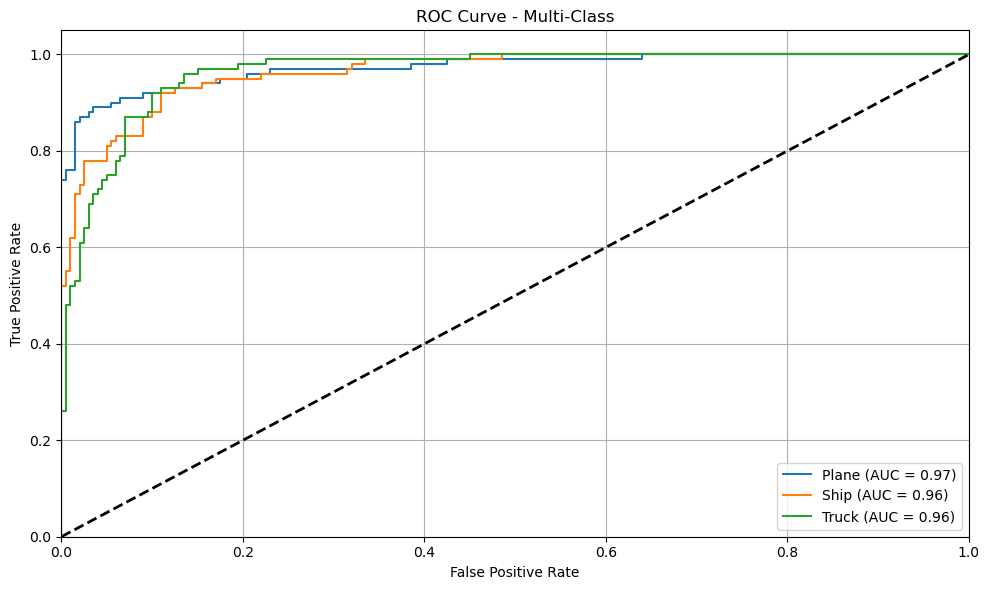

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_bs64.png


=== Training: VGG11BN_2a_no_dropout_weightdecay_scheduler (Batch size: 64) ===


Training VGG11BN_2a_no_dropout_weightdecay_scheduler_bs64_20250414_213904: 100%|██████████| 1440/1440 [02:05<00:00, 11.51batch/s, epoch=60/60, phase=val, loss=0.3533, acc=0.8864]  



Best Val Accuracy: 0.8800
Total training time: 125.06s


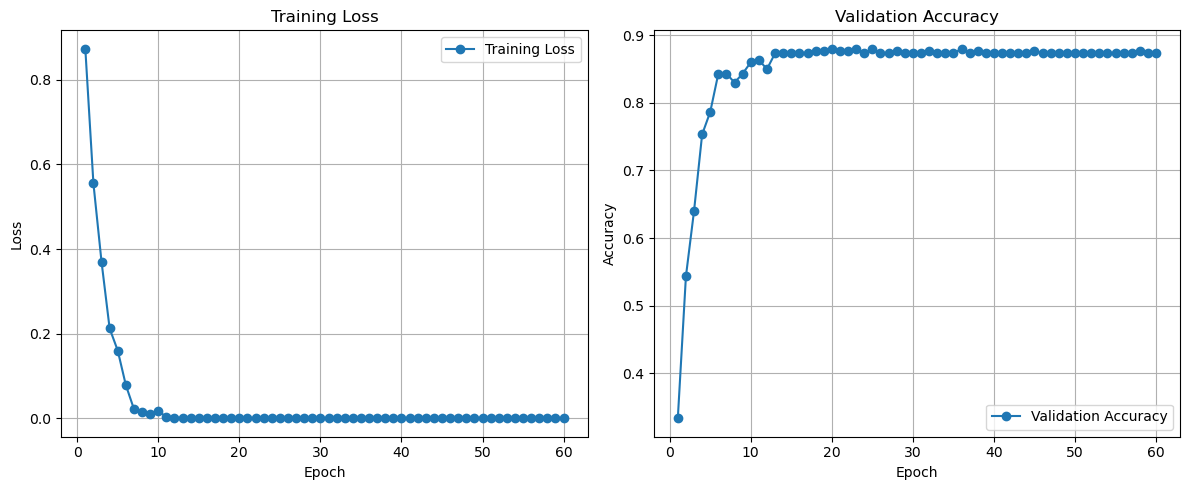

              precision    recall  f1-score   support

       Plane       0.95      0.86      0.90       100
        Ship       0.84      0.87      0.85       100
       Truck       0.85      0.89      0.87       100

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.5160, Validation Accuracy: 0.8733 |
+------------------------------------------------------+


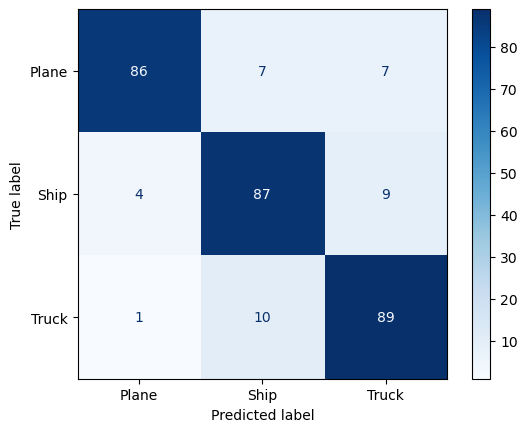

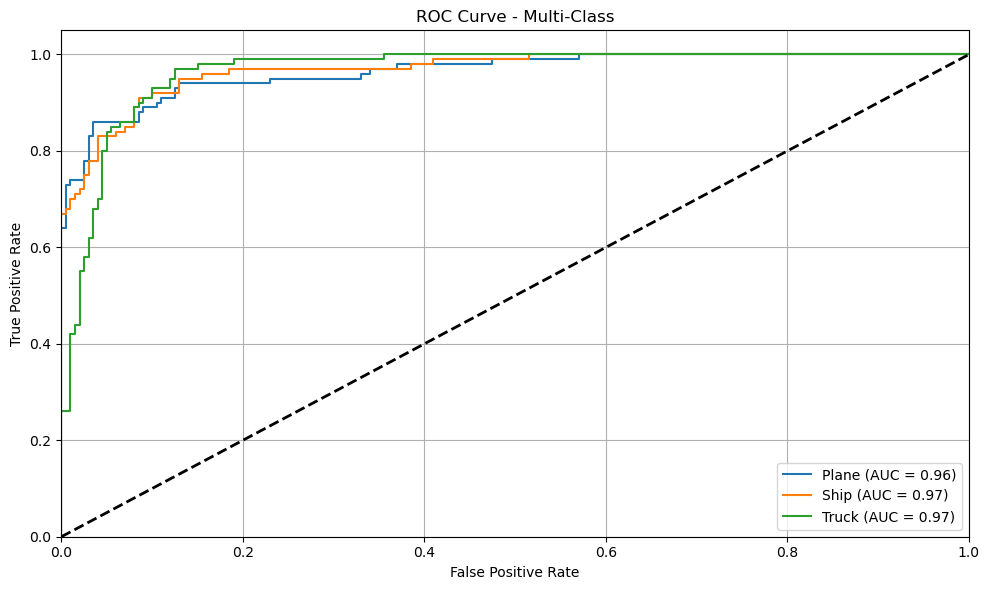

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_scheduler_bs64.png


=== Training: VGG11BN_2c_with_dropout (Batch size: 64) ===


Training VGG11BN_2c_with_dropout_bs64_20250414_214111: 100%|██████████| 1440/1440 [02:03<00:00, 11.67batch/s, epoch=60/60, phase=val, loss=1.0512, acc=0.8409]  



Best Val Accuracy: 0.8833
Total training time: 123.45s


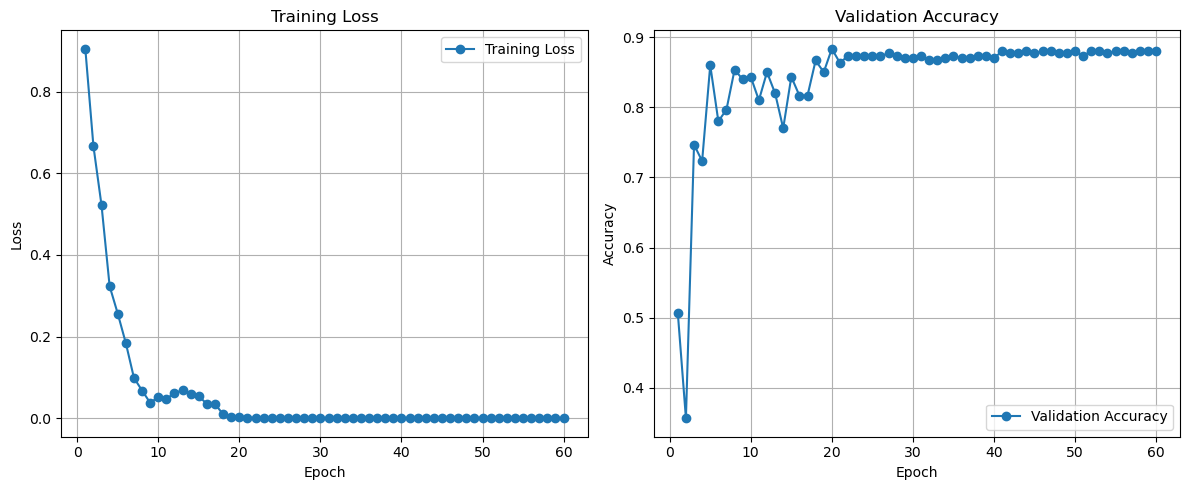

              precision    recall  f1-score   support

       Plane       0.95      0.88      0.91       100
        Ship       0.87      0.86      0.86       100
       Truck       0.83      0.90      0.87       100

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.7719, Validation Accuracy: 0.8800 |
+------------------------------------------------------+


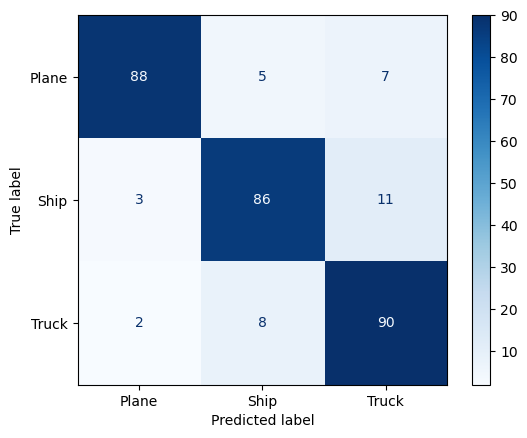

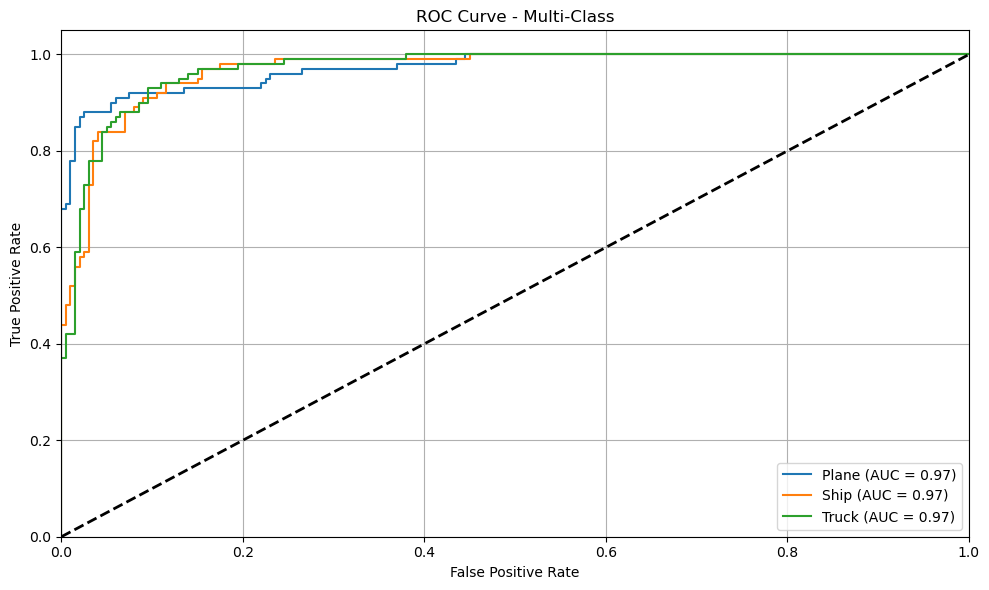

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_bs64.png


=== Training: VGG11BN_2c_with_dropout_weightdecay (Batch size: 64) ===


Training VGG11BN_2c_with_dropout_weightdecay_bs64_20250414_214317: 100%|██████████| 1440/1440 [02:04<00:00, 11.53batch/s, epoch=60/60, phase=val, loss=0.6904, acc=0.9091]  



Best Val Accuracy: 0.8733
Total training time: 124.95s


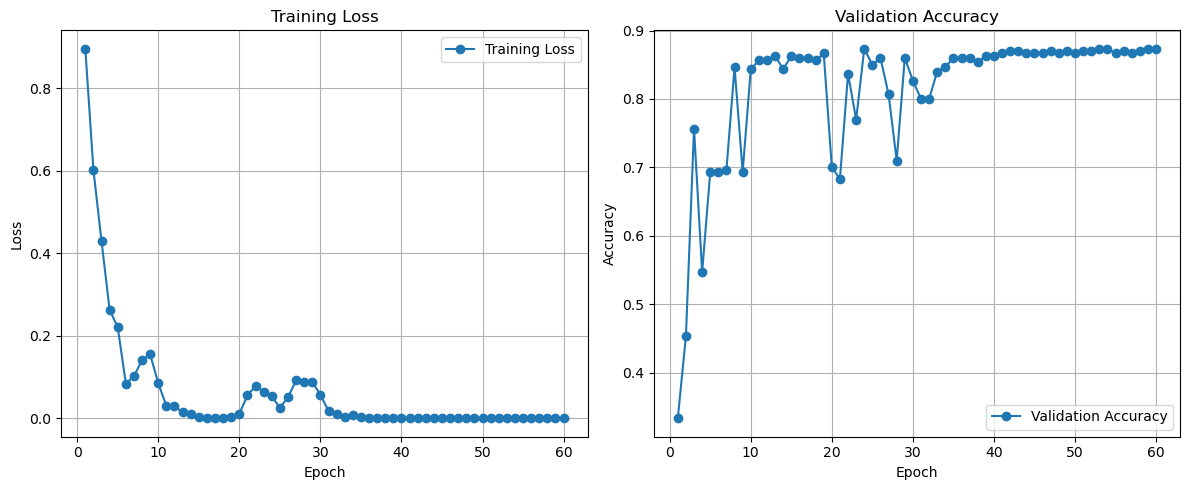

              precision    recall  f1-score   support

       Plane       0.89      0.89      0.89       100
        Ship       0.87      0.85      0.86       100
       Truck       0.86      0.88      0.87       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.7203, Validation Accuracy: 0.8733 |
+------------------------------------------------------+


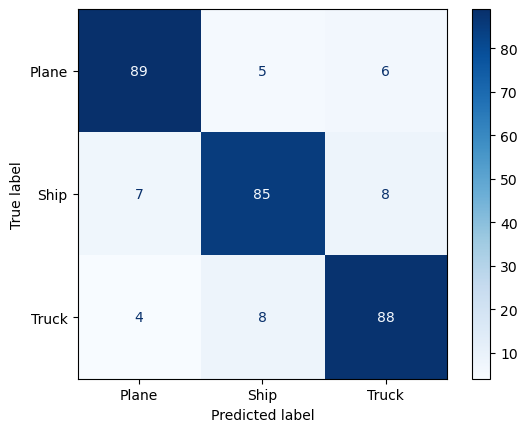

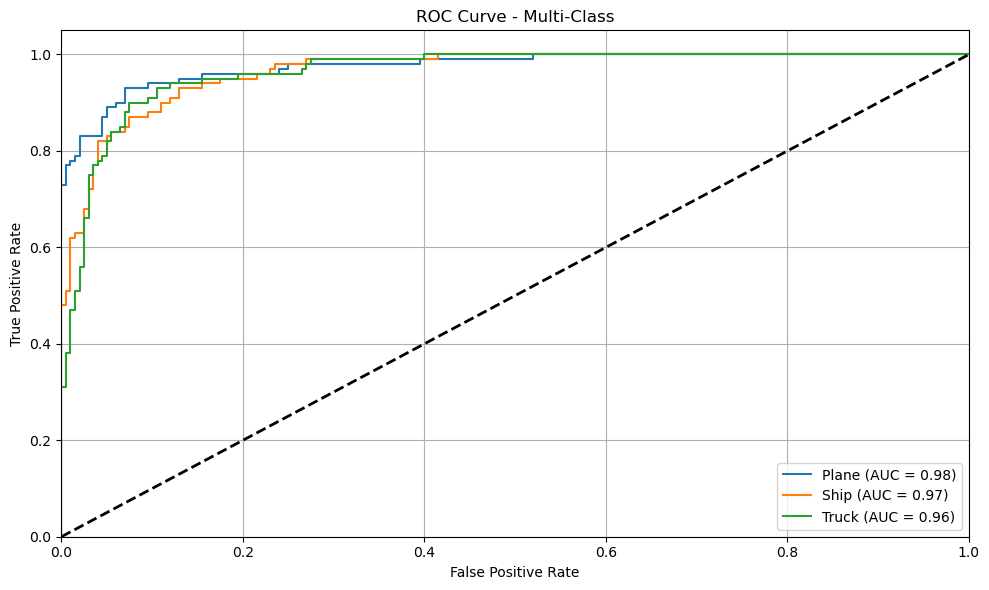

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_bs64.png


=== Training: VGG11BN_2c_with_dropout_weightdecay_scheduler (Batch size: 64) ===


Training VGG11BN_2c_with_dropout_weightdecay_scheduler_bs64_20250414_214524: 100%|██████████| 1440/1440 [02:05<00:00, 11.52batch/s, epoch=60/60, phase=val, loss=0.3770, acc=0.9318]  



Best Val Accuracy: 0.8833
Total training time: 125.03s


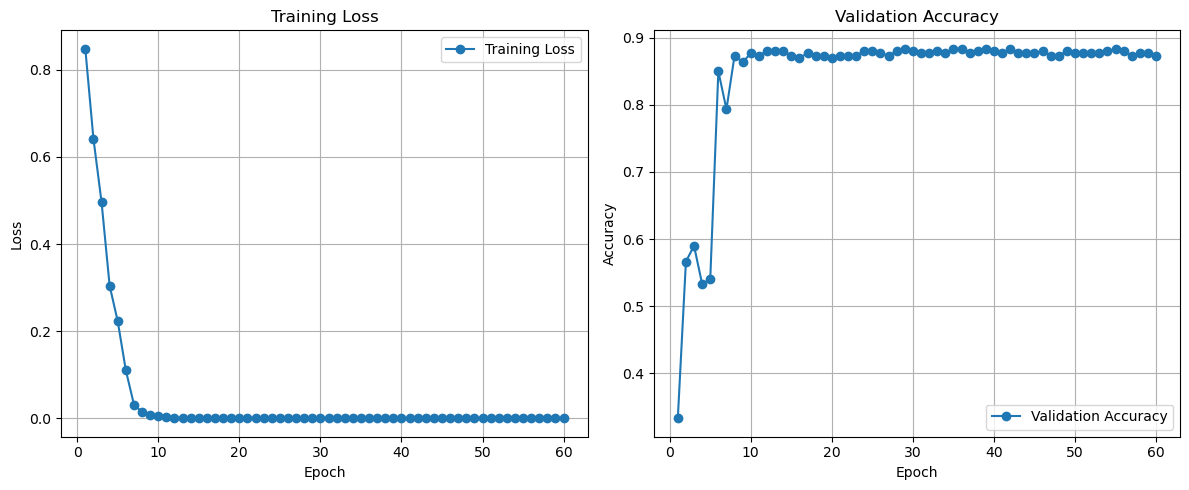

              precision    recall  f1-score   support

       Plane       0.94      0.85      0.89       100
        Ship       0.84      0.87      0.85       100
       Truck       0.85      0.90      0.87       100

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.5213, Validation Accuracy: 0.8733 |
+------------------------------------------------------+


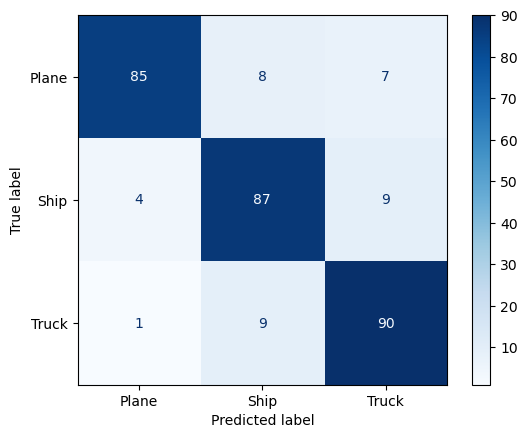

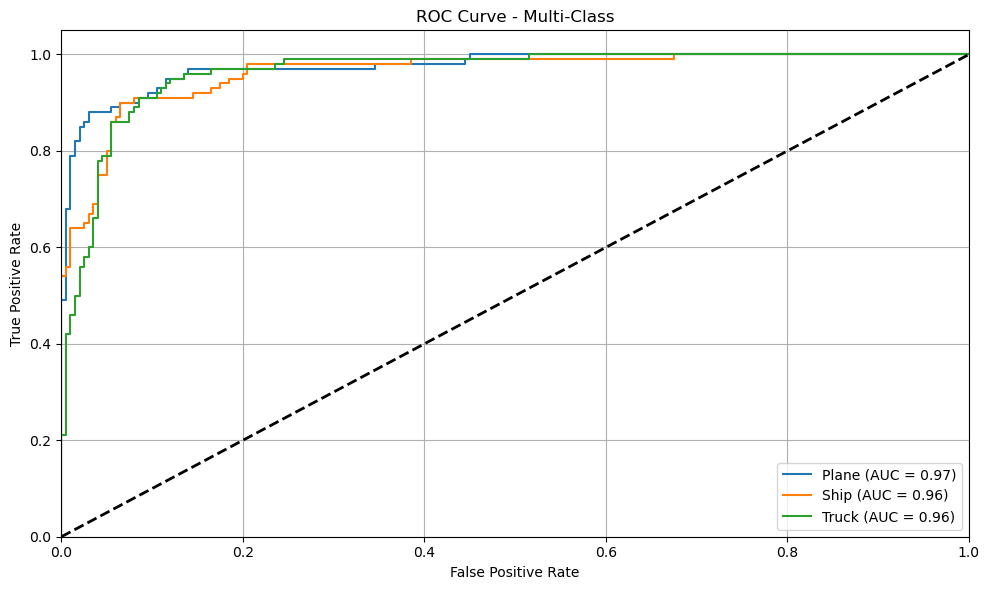

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_scheduler_bs64.png


In [4]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_multiclass_roc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels)
val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "VGG11BN_2a_no_dropout",
        "dropout": False,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay_scheduler",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "VGG11BN_2c_with_dropout",
        "dropout": True,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay_scheduler",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "VGG11BN_2a_no_dropout",
        "dropout": False,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 64
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 64
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay_scheduler",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 64
    },
    {
        "name": "VGG11BN_2c_with_dropout",
        "dropout": True,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 64
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 64
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay_scheduler",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 64
    },
    
]


# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Model, optimizer, scheduler
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=cfg["weight_decay"])
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5) if cfg["use_scheduler"] else None

    # Train
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=60,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}"  # reflects batch size in filenames
    )

    # Evaluate
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    # Plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    
    plot_multiclass_roc(
        model=trained_model,
        dataloader=dataloaders['val'],
        device=device,
        num_classes=3,
        class_names=['Plane', 'Ship', 'Truck'],
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}"
    )




=== Training: VGG11BN_2a_no_dropout (Batch size: 128) ===


Training VGG11BN_2a_no_dropout_bs128_20250414_215239: 100%|██████████| 780/780 [01:51<00:00,  6.99batch/s, epoch=60/60, phase=val, loss=0.4169, acc=0.9318]  



Best Val Accuracy: 0.8933
Total training time: 111.51s


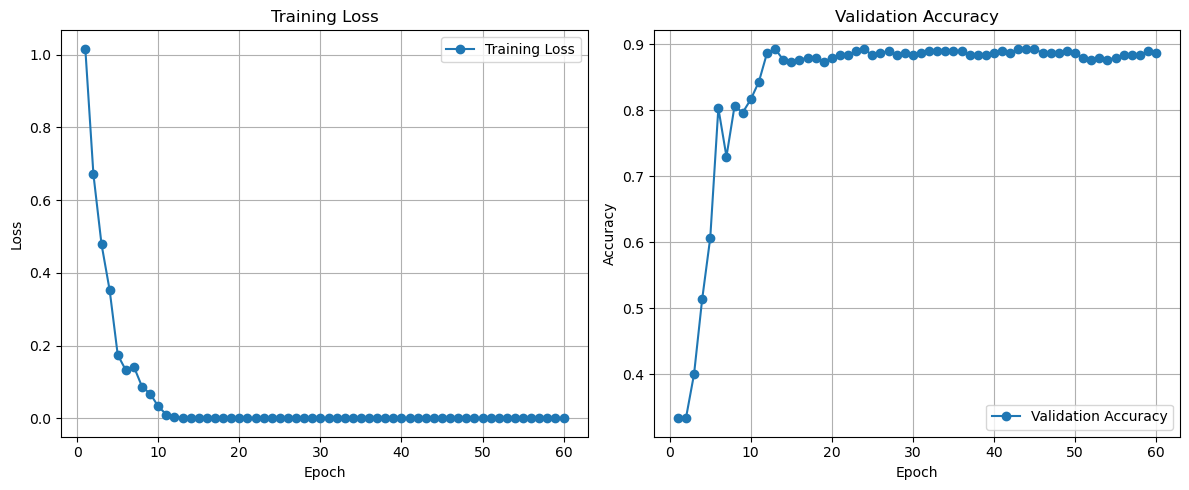

              precision    recall  f1-score   support

       Plane       0.95      0.89      0.92       100
        Ship       0.86      0.87      0.87       100
       Truck       0.86      0.90      0.88       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.7309, Validation Accuracy: 0.8867 |
+------------------------------------------------------+


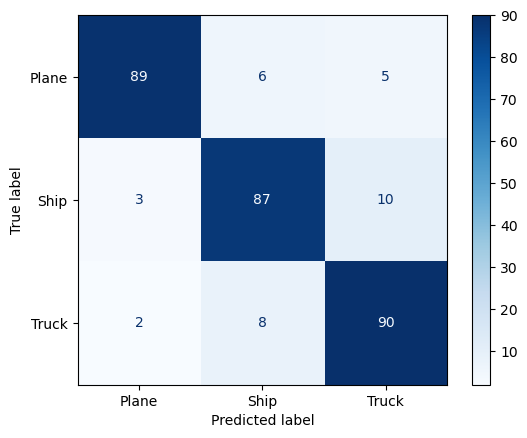

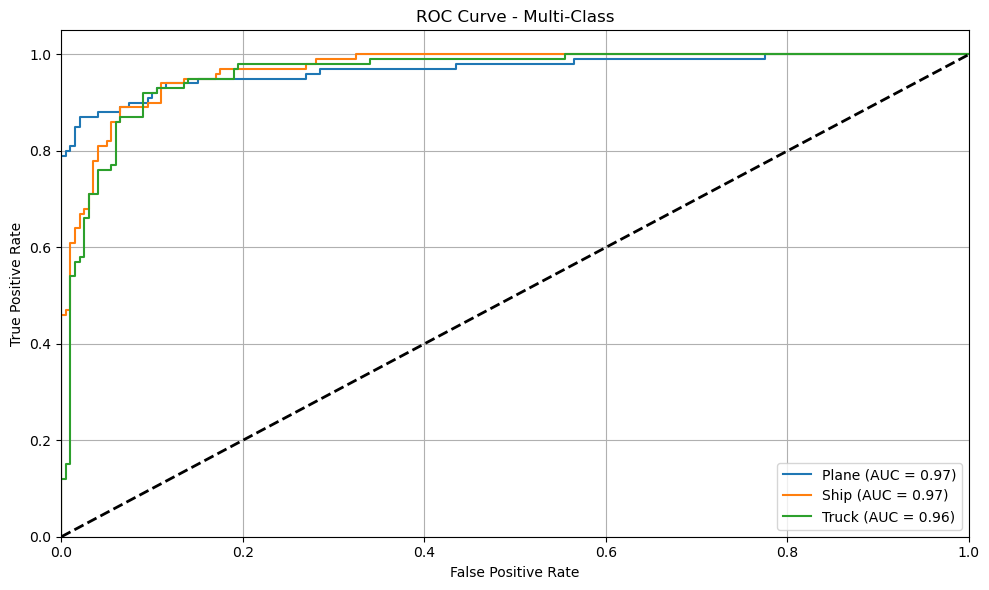

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_bs128.png


=== Training: VGG11BN_2a_no_dropout_weightdecay (Batch size: 128) ===


Training VGG11BN_2a_no_dropout_weightdecay_bs128_20250414_215433: 100%|██████████| 780/780 [01:55<00:00,  6.78batch/s, epoch=60/60, phase=val, loss=0.7688, acc=0.8636]  



Best Val Accuracy: 0.8833
Total training time: 115.08s


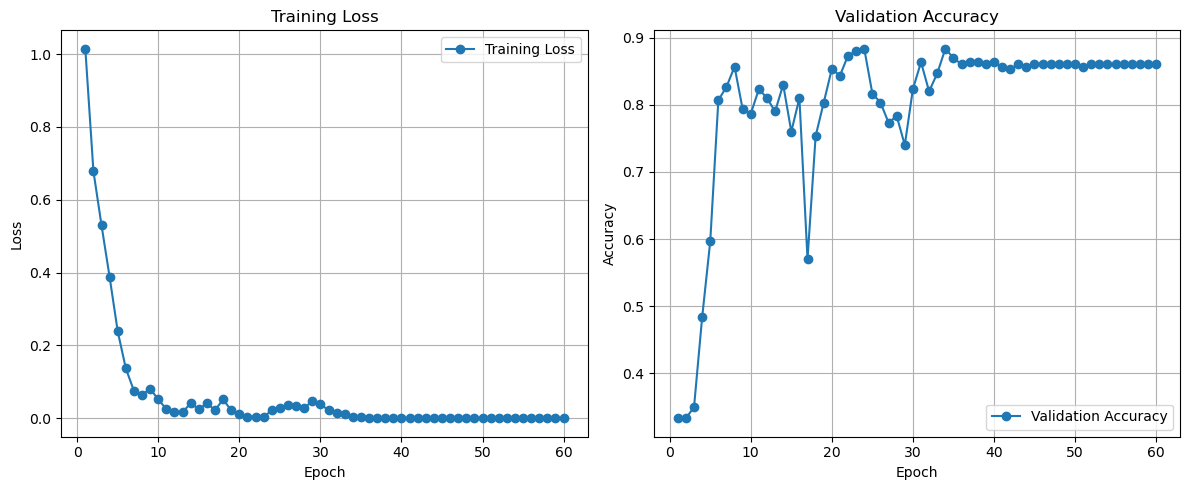

              precision    recall  f1-score   support

       Plane       0.94      0.88      0.91       100
        Ship       0.82      0.87      0.84       100
       Truck       0.83      0.83      0.83       100

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

+------------------------------------------------------+
| Validation Loss: 0.7019, Validation Accuracy: 0.8600 |
+------------------------------------------------------+


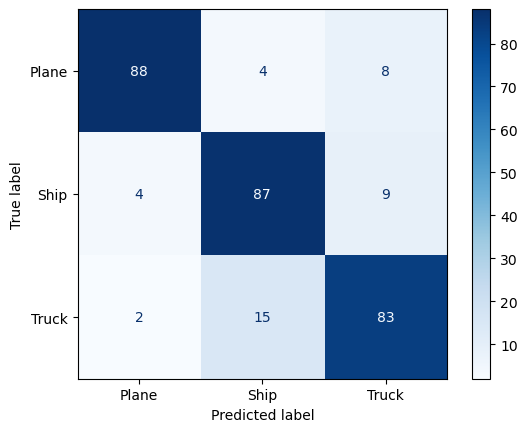

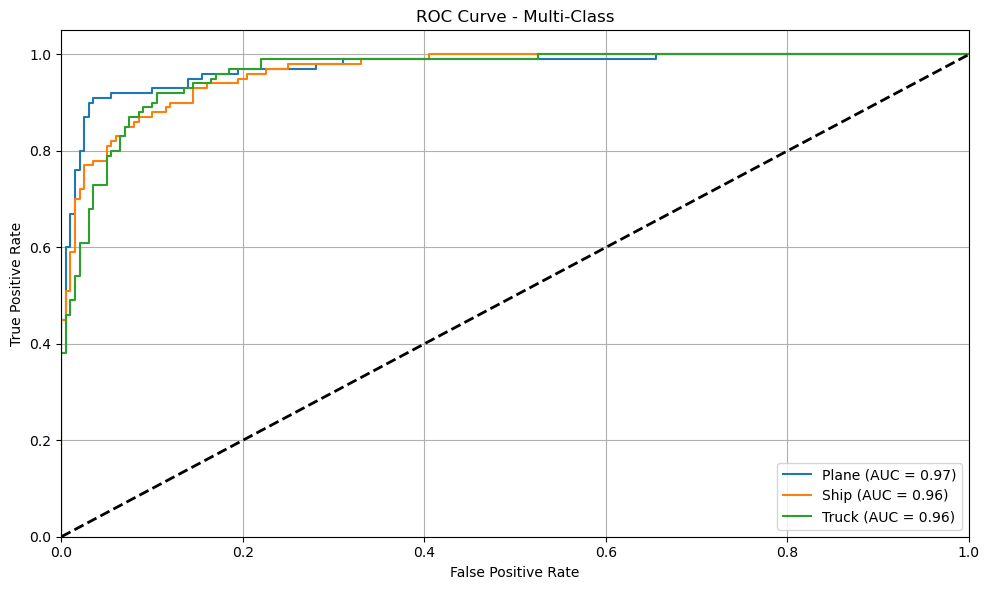

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_bs128.png


=== Training: VGG11BN_2a_no_dropout_weightdecay_scheduler (Batch size: 128) ===


Training VGG11BN_2a_no_dropout_weightdecay_scheduler_bs128_20250414_215630: 100%|██████████| 780/780 [01:56<00:00,  6.71batch/s, epoch=60/60, phase=val, loss=0.3199, acc=0.9318]  



Best Val Accuracy: 0.8867
Total training time: 116.33s


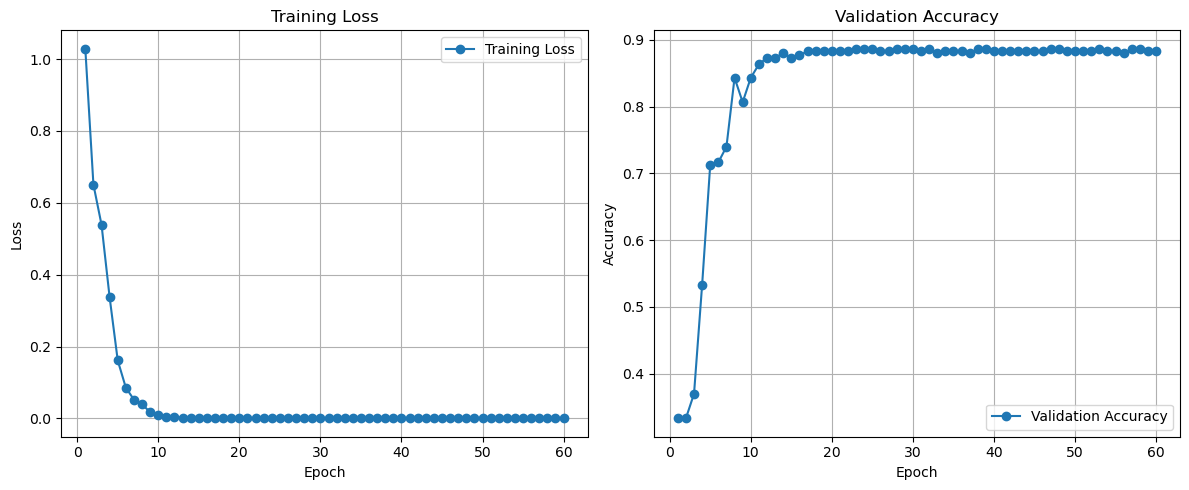

              precision    recall  f1-score   support

       Plane       0.96      0.88      0.92       100
        Ship       0.85      0.89      0.87       100
       Truck       0.85      0.88      0.87       100

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.4033, Validation Accuracy: 0.8833 |
+------------------------------------------------------+


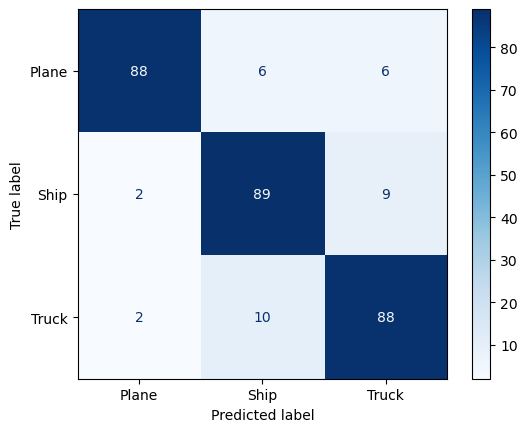

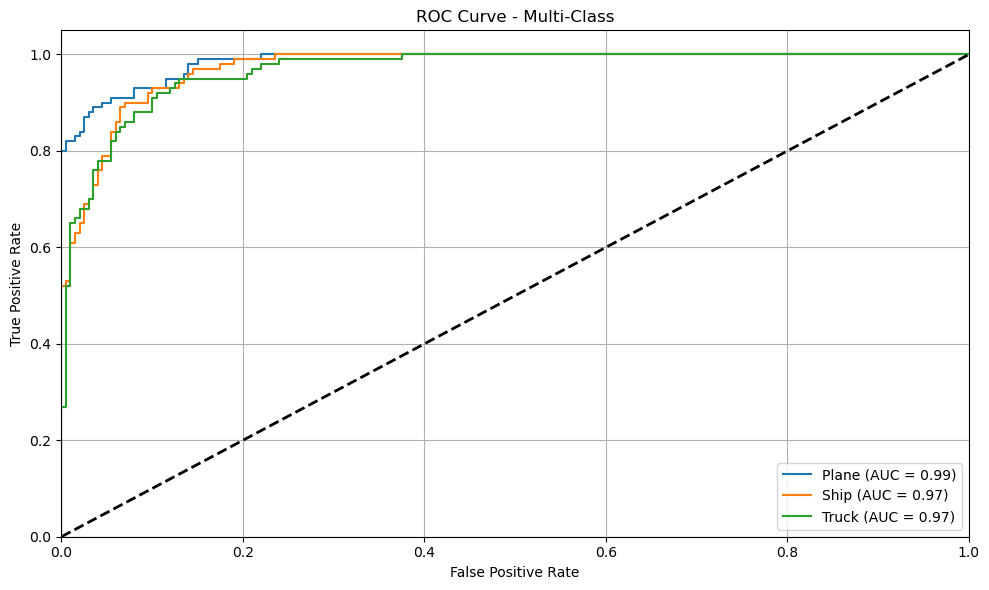

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_scheduler_bs128.png


=== Training: VGG11BN_2c_with_dropout (Batch size: 128) ===


Training VGG11BN_2c_with_dropout_bs128_20250414_215829: 100%|██████████| 780/780 [01:55<00:00,  6.77batch/s, epoch=60/60, phase=val, loss=0.6715, acc=0.8864]  



Best Val Accuracy: 0.8767
Total training time: 115.25s


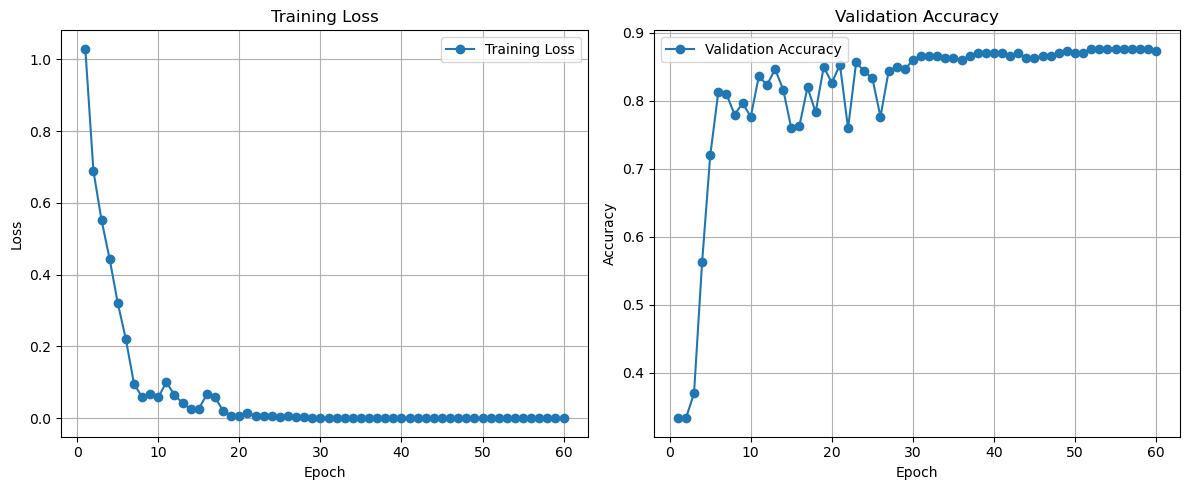

              precision    recall  f1-score   support

       Plane       0.97      0.88      0.92       100
        Ship       0.81      0.88      0.85       100
       Truck       0.85      0.86      0.86       100

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.8070, Validation Accuracy: 0.8733 |
+------------------------------------------------------+


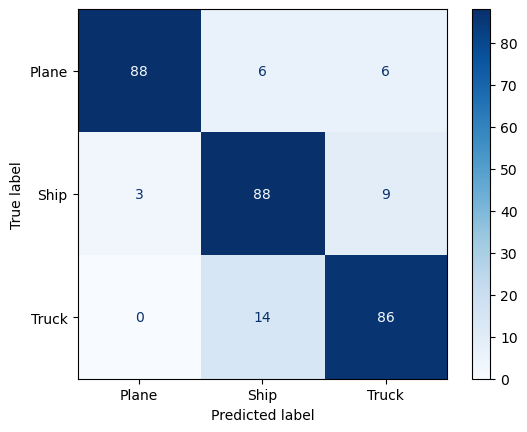

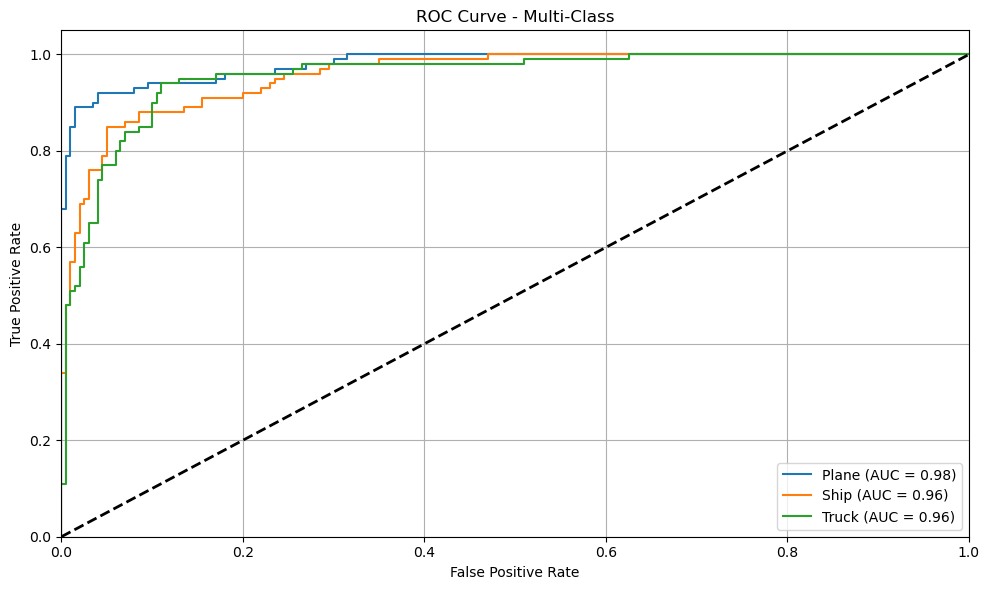

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_bs128.png


=== Training: VGG11BN_2c_with_dropout_weightdecay (Batch size: 128) ===


Training VGG11BN_2c_with_dropout_weightdecay_bs128_20250414_220026: 100%|██████████| 780/780 [01:56<00:00,  6.69batch/s, epoch=60/60, phase=val, loss=0.7742, acc=0.8864]  



Best Val Accuracy: 0.8900
Total training time: 116.62s


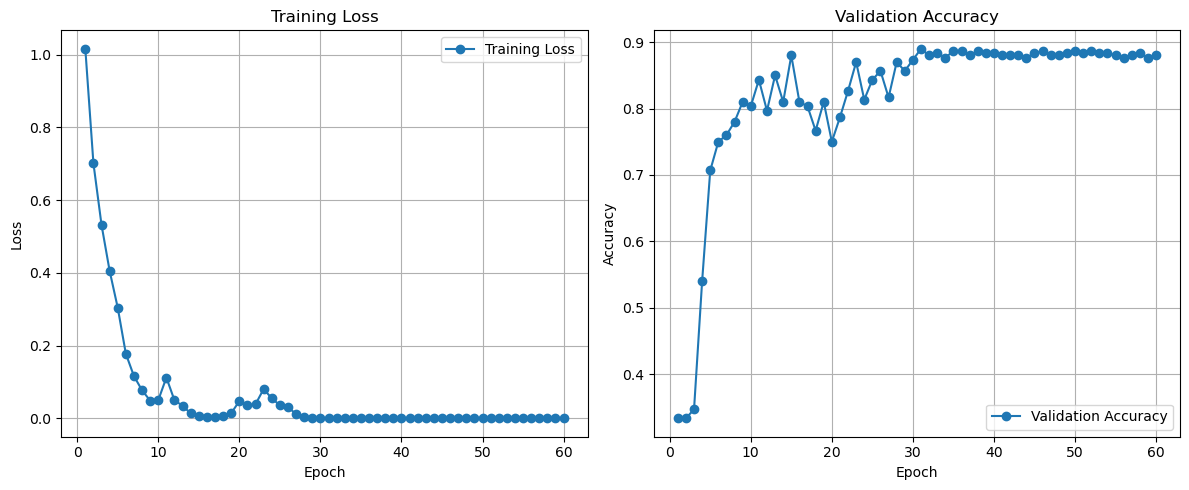

              precision    recall  f1-score   support

       Plane       0.97      0.85      0.90       100
        Ship       0.82      0.93      0.87       100
       Truck       0.87      0.86      0.86       100

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.6230, Validation Accuracy: 0.8800 |
+------------------------------------------------------+


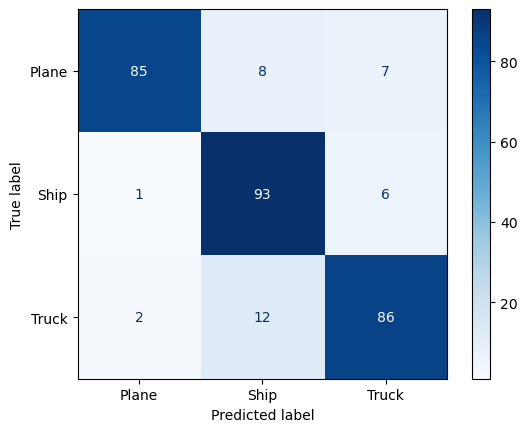

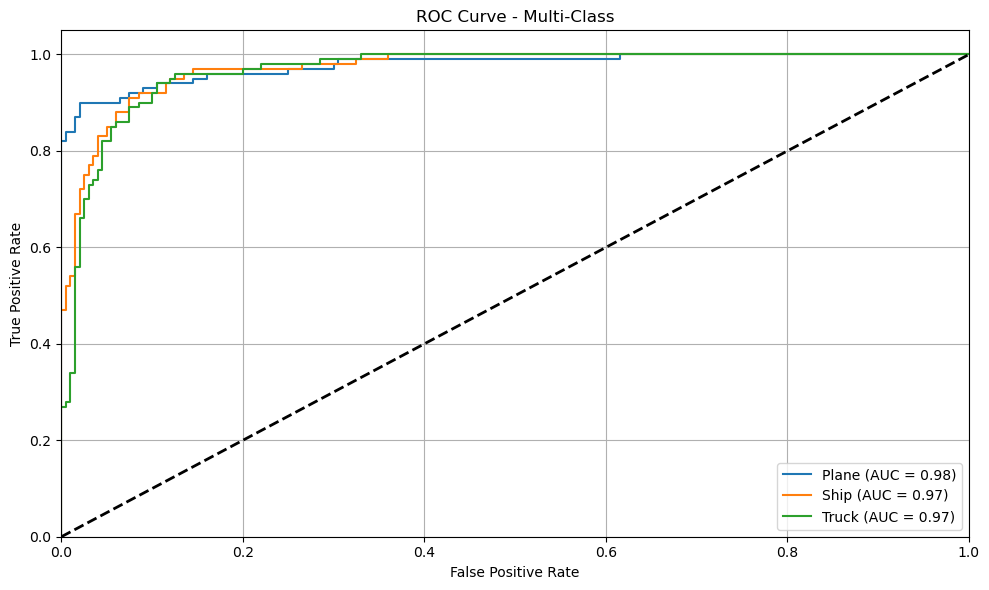

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_bs128.png


=== Training: VGG11BN_2c_with_dropout_weightdecay_scheduler (Batch size: 128) ===


Training VGG11BN_2c_with_dropout_weightdecay_scheduler_bs128_20250414_220225: 100%|██████████| 780/780 [01:56<00:00,  6.69batch/s, epoch=60/60, phase=val, loss=0.5101, acc=0.8864]  



Best Val Accuracy: 0.8833
Total training time: 116.55s


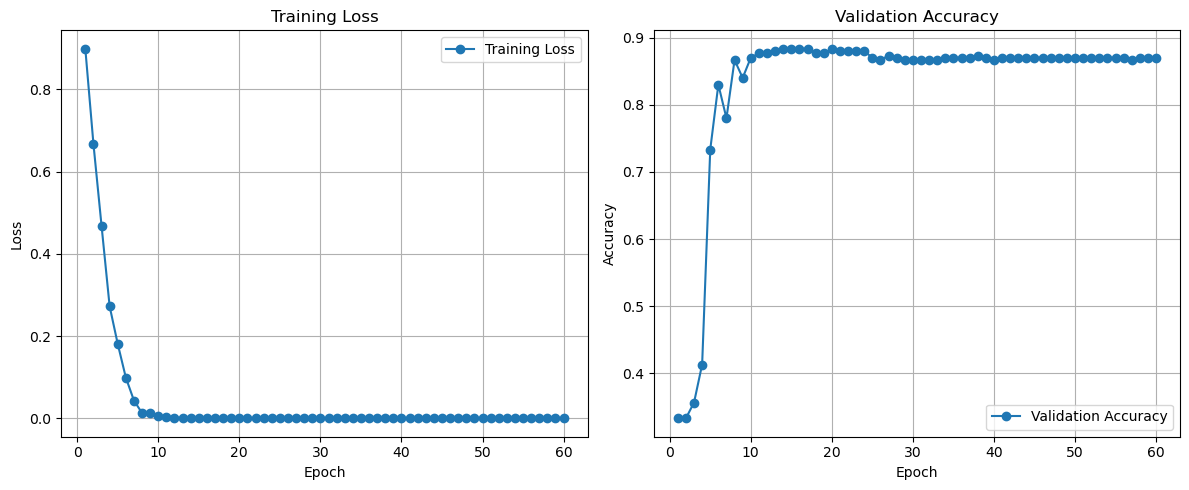

              precision    recall  f1-score   support

       Plane       0.96      0.85      0.90       100
        Ship       0.84      0.85      0.85       100
       Truck       0.83      0.91      0.87       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.5157, Validation Accuracy: 0.8700 |
+------------------------------------------------------+


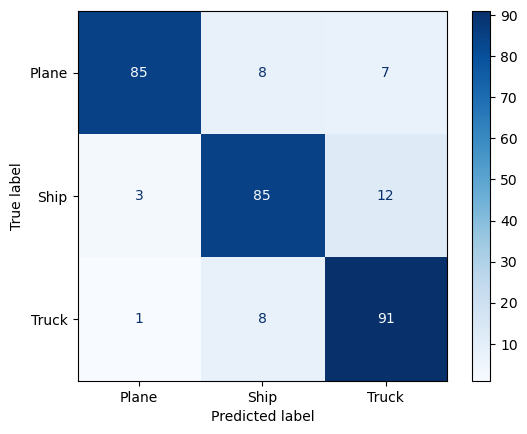

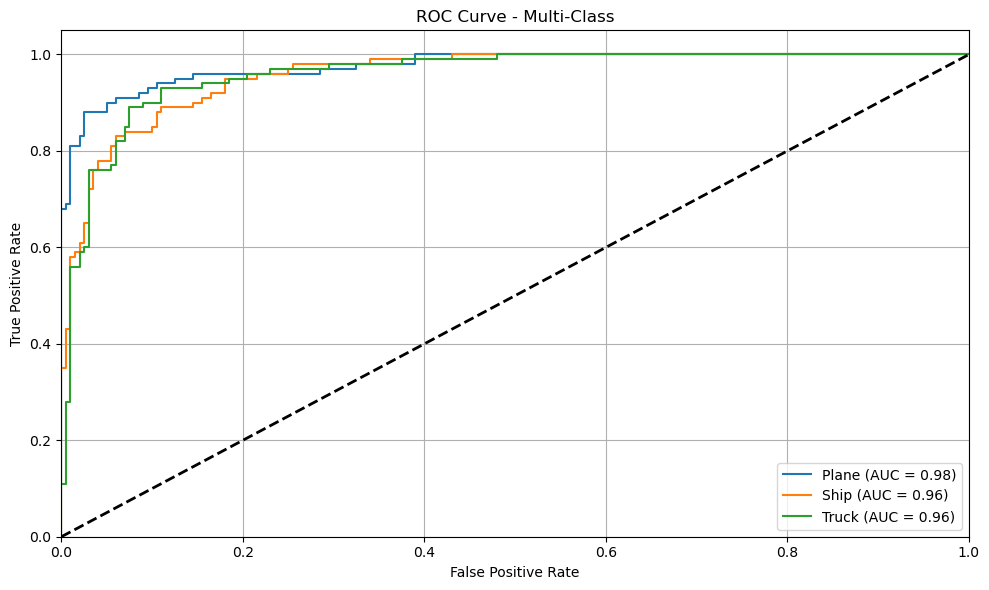

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_scheduler_bs128.png


=== Training: VGG11BN_2a_no_dropout (Batch size: 256) ===


Training VGG11BN_2a_no_dropout_bs256_20250414_220424: 100%|██████████| 420/420 [01:52<00:00,  3.73batch/s, epoch=60/60, phase=val, loss=0.6749, acc=0.8864]  



Best Val Accuracy: 0.8700
Total training time: 112.70s


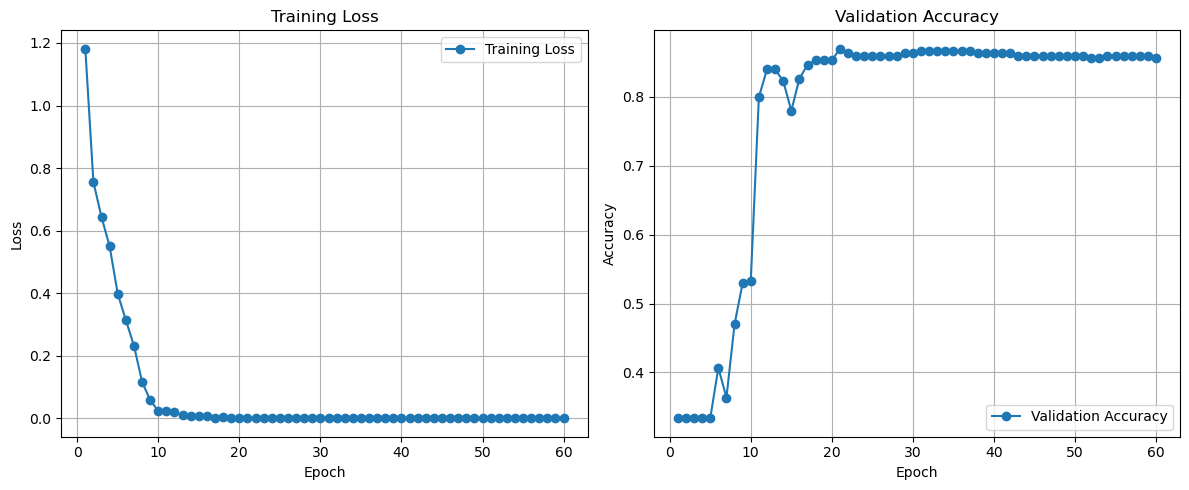

              precision    recall  f1-score   support

       Plane       0.94      0.87      0.90       100
        Ship       0.84      0.83      0.83       100
       Truck       0.81      0.87      0.84       100

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

+------------------------------------------------------+
| Validation Loss: 0.7001, Validation Accuracy: 0.8567 |
+------------------------------------------------------+


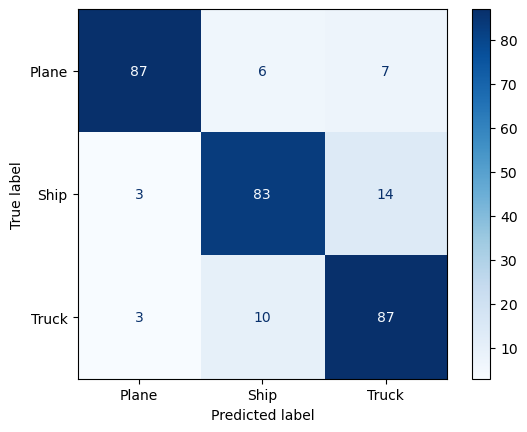

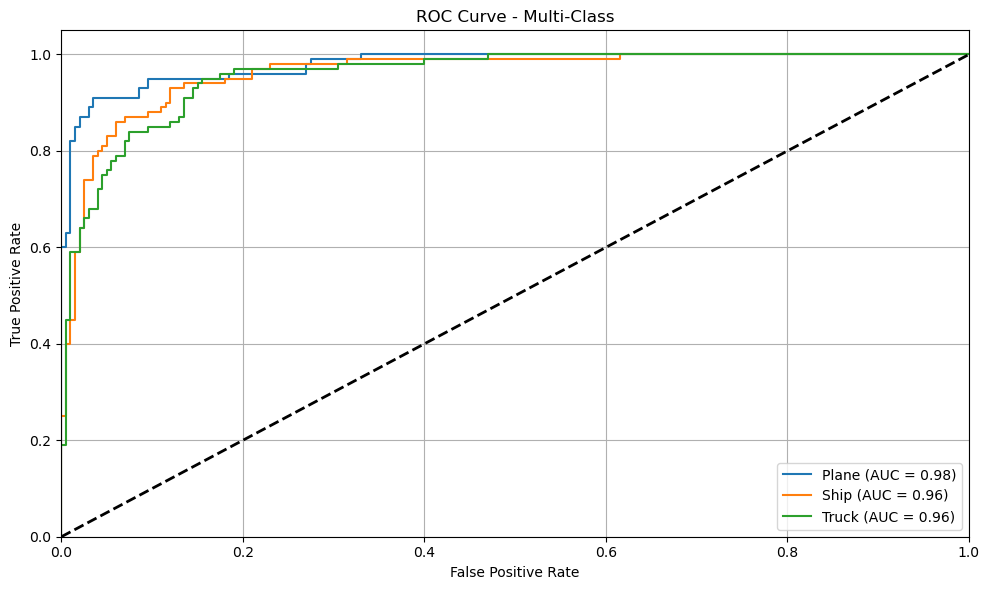

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_bs256.png


=== Training: VGG11BN_2a_no_dropout_weightdecay (Batch size: 256) ===


Training VGG11BN_2a_no_dropout_weightdecay_bs256_20250414_220619: 100%|██████████| 420/420 [01:52<00:00,  3.72batch/s, epoch=60/60, phase=val, loss=0.6275, acc=0.8864]  



Best Val Accuracy: 0.8667
Total training time: 112.90s


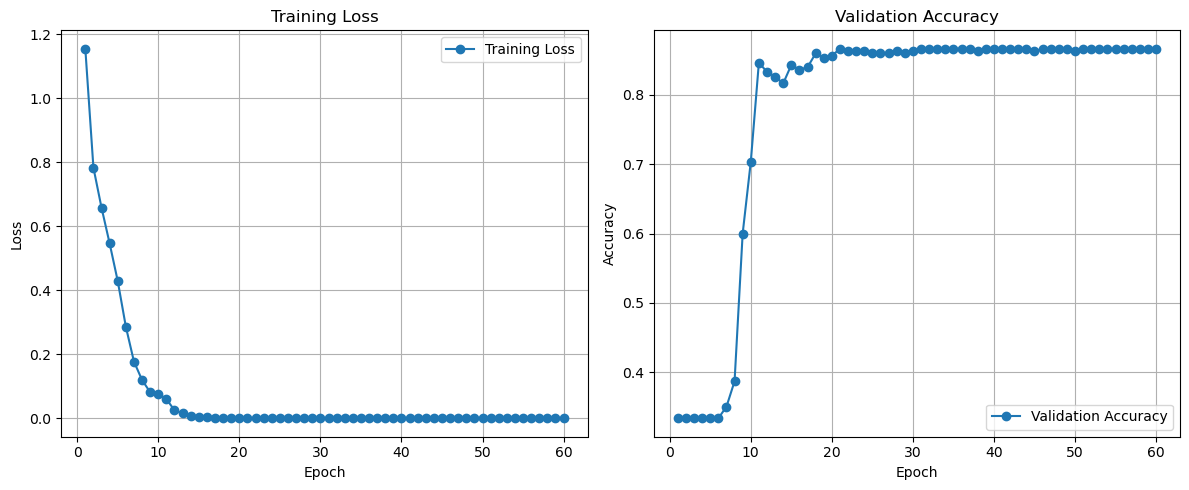

              precision    recall  f1-score   support

       Plane       0.96      0.85      0.90       100
        Ship       0.82      0.87      0.84       100
       Truck       0.84      0.88      0.86       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.6268, Validation Accuracy: 0.8667 |
+------------------------------------------------------+


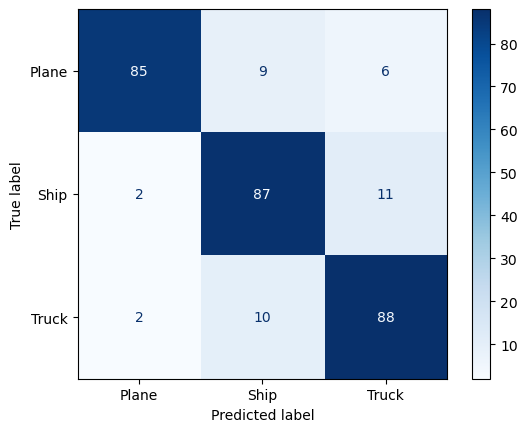

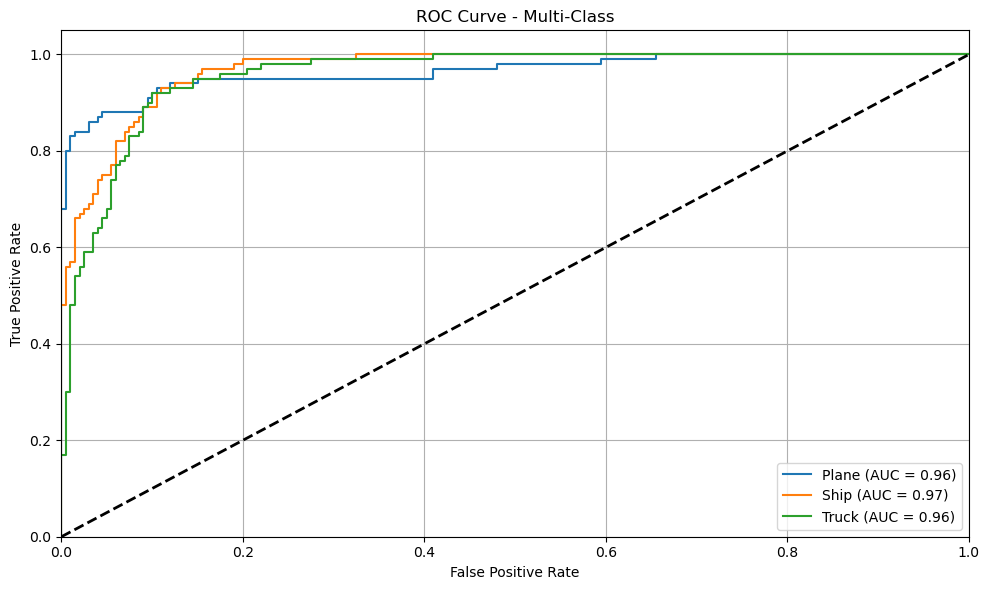

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_bs256.png


=== Training: VGG11BN_2a_no_dropout_weightdecay_scheduler (Batch size: 256) ===


Training VGG11BN_2a_no_dropout_weightdecay_scheduler_bs256_20250414_220814: 100%|██████████| 420/420 [01:53<00:00,  3.71batch/s, epoch=60/60, phase=val, loss=0.2035, acc=0.9091]  



Best Val Accuracy: 0.8700
Total training time: 113.12s


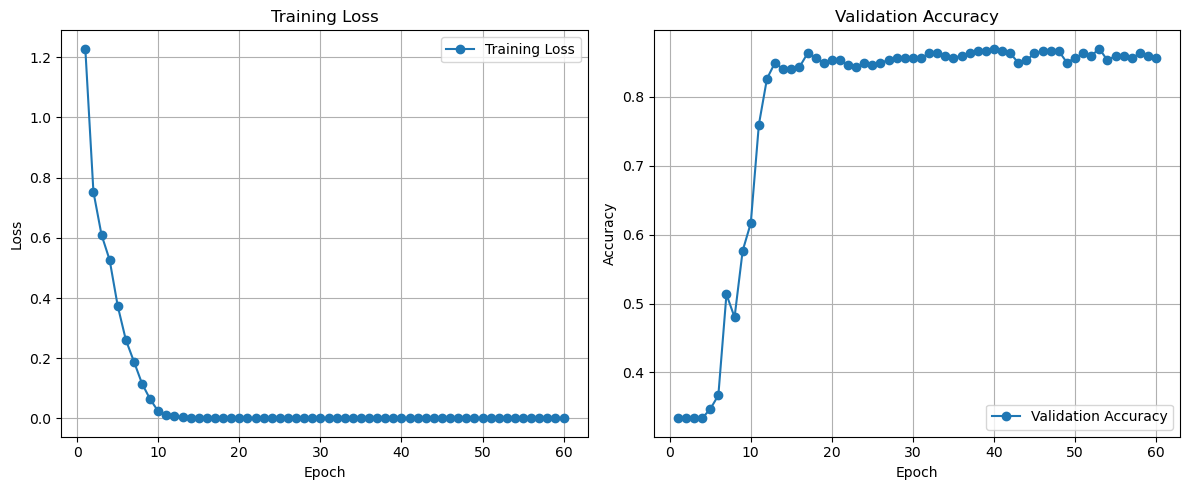

              precision    recall  f1-score   support

       Plane       0.94      0.83      0.88       100
        Ship       0.84      0.88      0.86       100
       Truck       0.80      0.86      0.83       100

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

+------------------------------------------------------+
| Validation Loss: 0.4915, Validation Accuracy: 0.8567 |
+------------------------------------------------------+


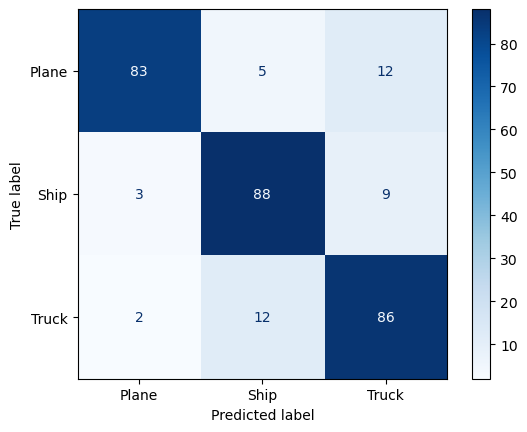

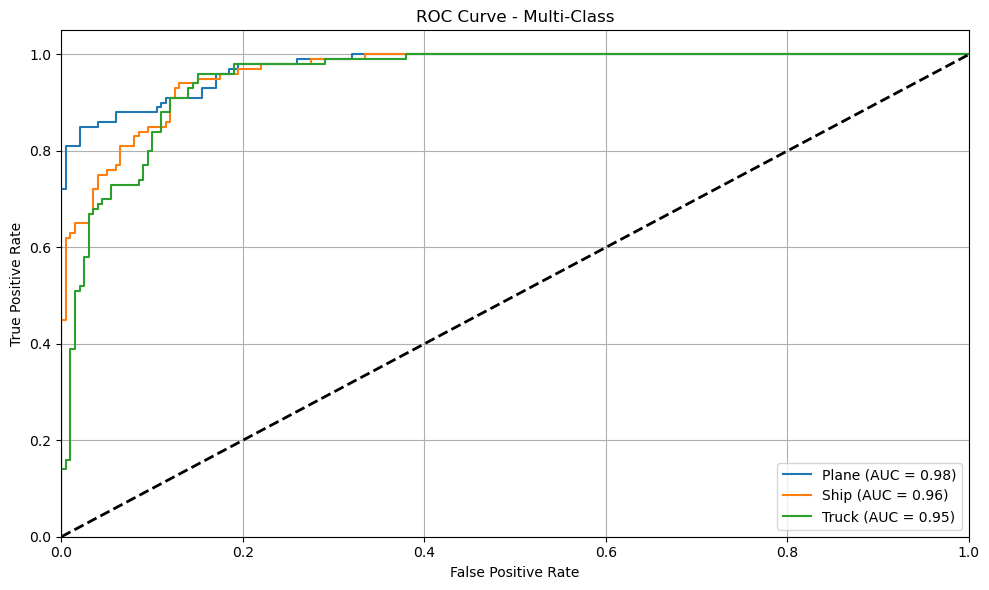

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_scheduler_bs256.png


=== Training: VGG11BN_2c_with_dropout (Batch size: 256) ===


Training VGG11BN_2c_with_dropout_bs256_20250414_221009: 100%|██████████| 420/420 [01:52<00:00,  3.73batch/s, epoch=60/60, phase=val, loss=0.4162, acc=0.9318]  



Best Val Accuracy: 0.8700
Total training time: 112.69s


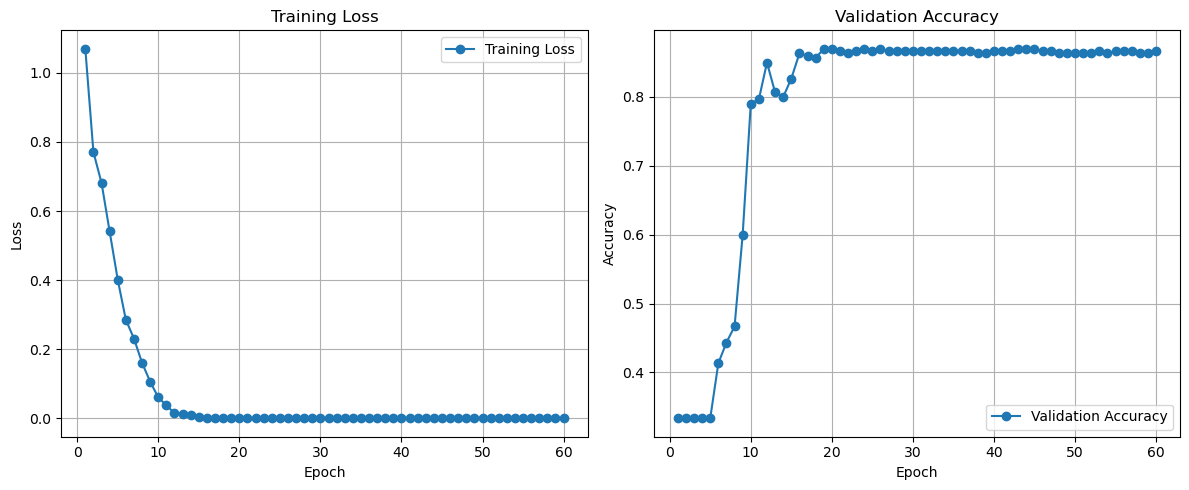

              precision    recall  f1-score   support

       Plane       0.96      0.88      0.92       100
        Ship       0.83      0.84      0.84       100
       Truck       0.82      0.88      0.85       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.6629, Validation Accuracy: 0.8667 |
+------------------------------------------------------+


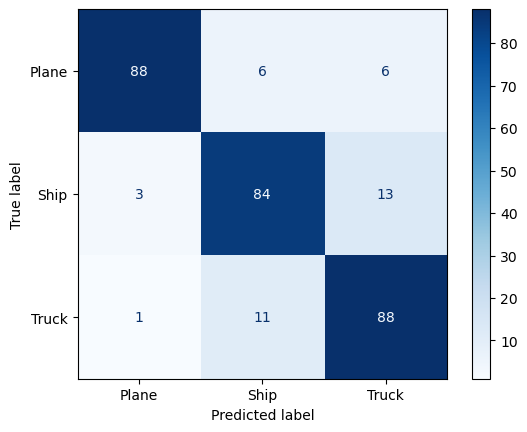

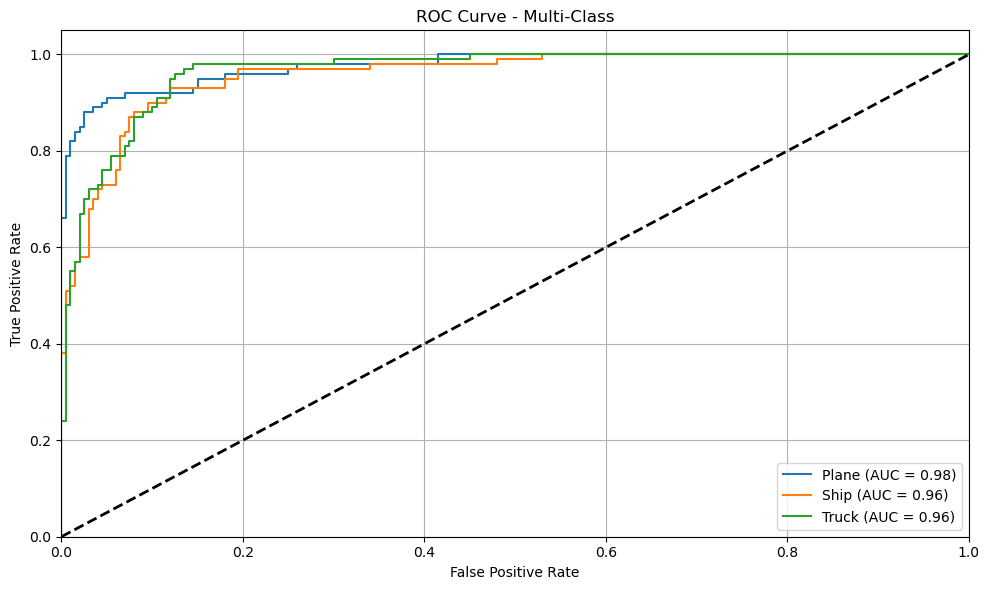

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_bs256.png


=== Training: VGG11BN_2c_with_dropout_weightdecay (Batch size: 256) ===


Training VGG11BN_2c_with_dropout_weightdecay_bs256_20250414_221204: 100%|██████████| 420/420 [01:53<00:00,  3.71batch/s, epoch=60/60, phase=val, loss=0.6313, acc=0.8409]  



Best Val Accuracy: 0.8767
Total training time: 113.24s


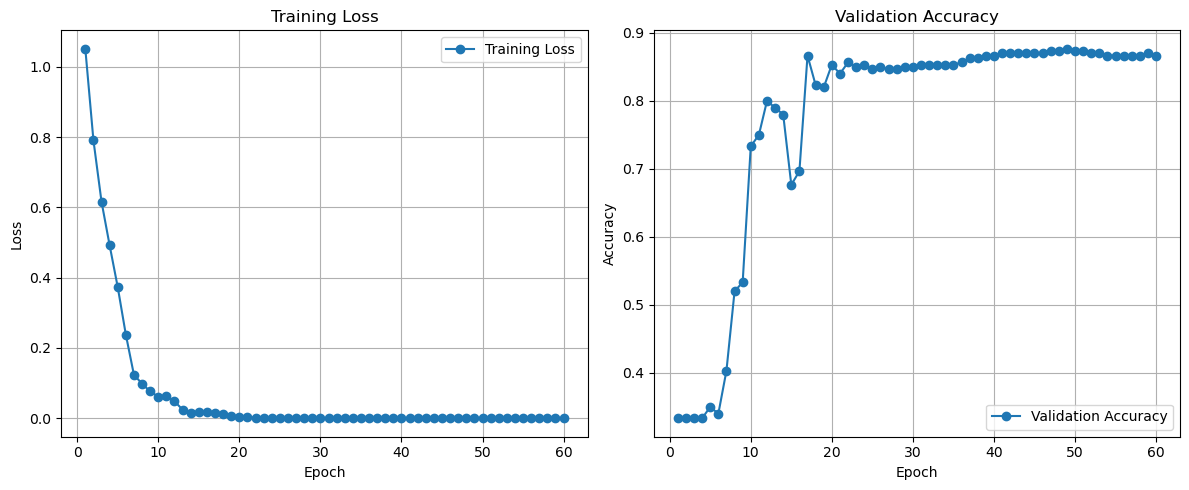

              precision    recall  f1-score   support

       Plane       0.94      0.84      0.89       100
        Ship       0.82      0.89      0.86       100
       Truck       0.84      0.87      0.86       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.6467, Validation Accuracy: 0.8667 |
+------------------------------------------------------+


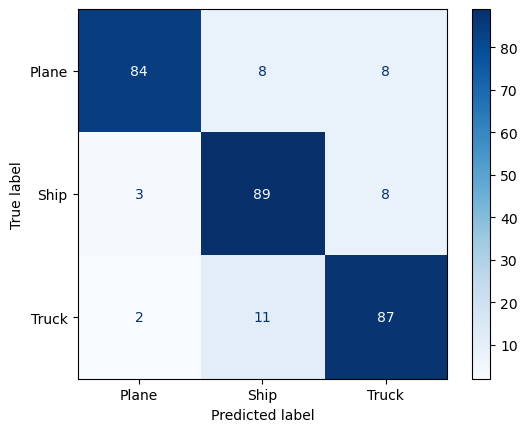

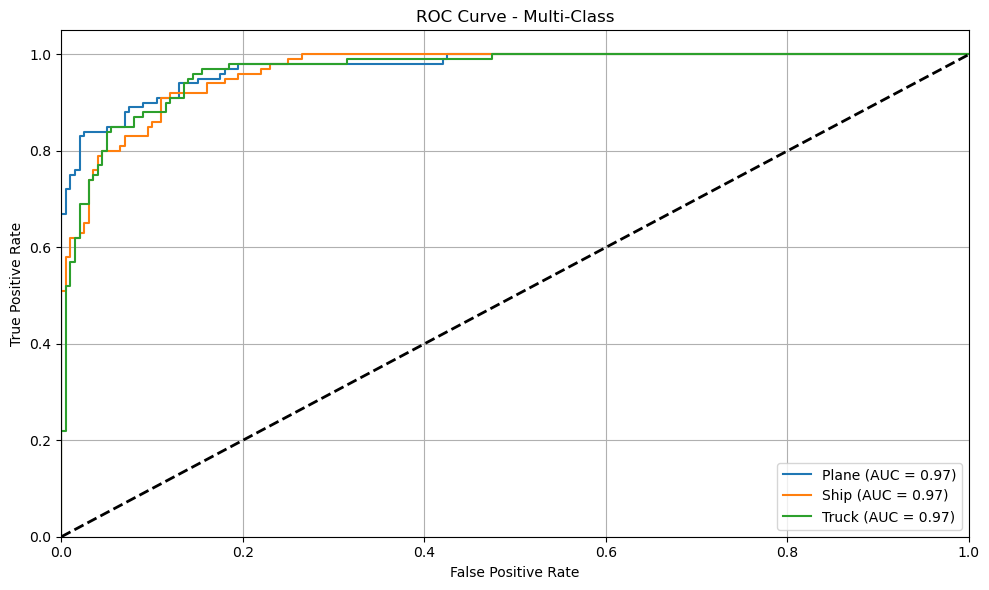

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_bs256.png


=== Training: VGG11BN_2c_with_dropout_weightdecay_scheduler (Batch size: 256) ===


Training VGG11BN_2c_with_dropout_weightdecay_scheduler_bs256_20250414_221400: 100%|██████████| 420/420 [01:52<00:00,  3.72batch/s, epoch=60/60, phase=val, loss=0.4005, acc=0.9091]  



Best Val Accuracy: 0.8667
Total training time: 112.92s


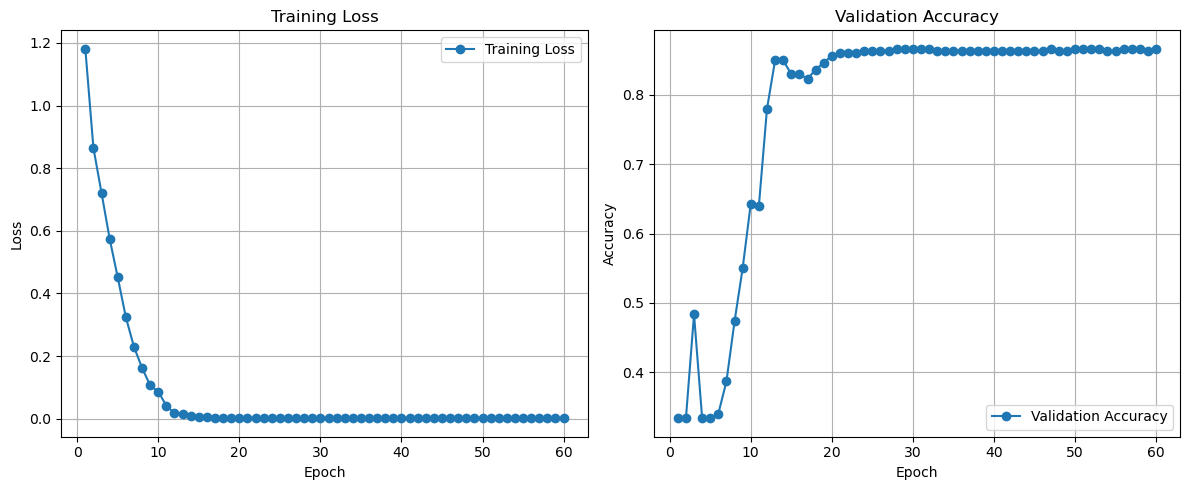

              precision    recall  f1-score   support

       Plane       0.93      0.86      0.90       100
        Ship       0.85      0.84      0.84       100
       Truck       0.83      0.90      0.86       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.5122, Validation Accuracy: 0.8667 |
+------------------------------------------------------+


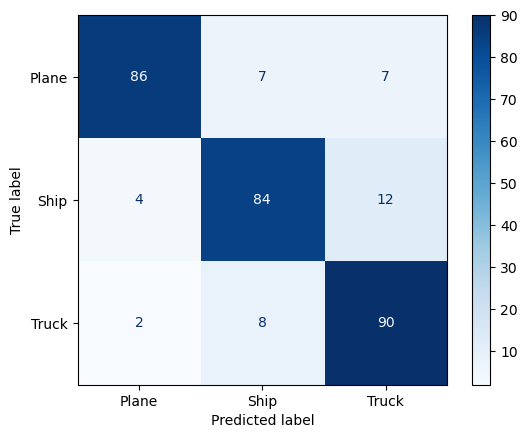

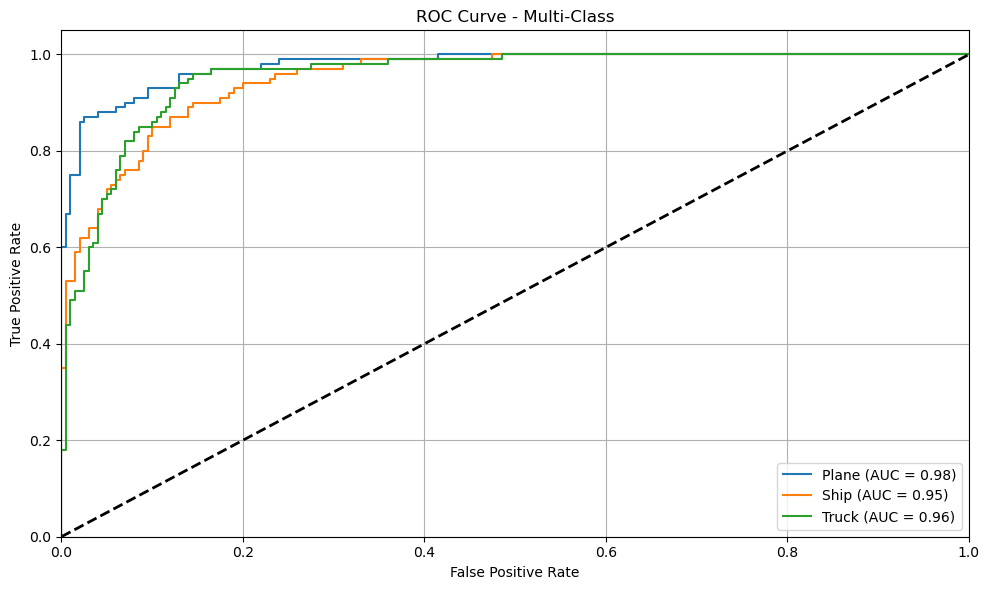

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_scheduler_bs256.png


In [5]:
# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels)
val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "VGG11BN_2a_no_dropout",
        "dropout": False,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 128
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 128
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay_scheduler",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 128
    },
    {
        "name": "VGG11BN_2c_with_dropout",
        "dropout": True,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 128
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 128
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay_scheduler",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 128
    },
    {
        "name": "VGG11BN_2a_no_dropout",
        "dropout": False,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 256
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 256
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay_scheduler",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 256
    },
    {
        "name": "VGG11BN_2c_with_dropout",
        "dropout": True,
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 256
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 256
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay_scheduler",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 256
    },
    
]


# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Model, optimizer, scheduler
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=cfg["weight_decay"])
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5) if cfg["use_scheduler"] else None

    # Train
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=60,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}"  # reflects batch size in filenames
    )

    # Evaluate
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    # Plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    
    plot_multiclass_roc(
        model=trained_model,
        dataloader=dataloaders['val'],
        device=device,
        num_classes=3,
        class_names=['Plane', 'Ship', 'Truck'],
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}"
    )